In [2]:

#Zomato Restaurant Analysis
### Introduction
#The basic idea of analyzing the Zomato dataset is to get a fair idea about the factors affecting the aggregate rating of
#each restaurant, establishment of different types of restaurant at different places, Bengaluru being one such city has more than
#12,000 restaurants with restaurants serving dishes from all over the world. With each day new restaurants opening the industry has’nt 
#been saturated yet and the demand is increasing day by day. Inspite of increasing demand it however has become difficult for new 
#restaurants to compete with established restaurants. Most of them serving the same food. Bengaluru being an IT capital of India. 
#Most of the people here are dependent mainly on the restaurant food as they don’t have time to cook for themselves. With such an 
#overwhelming demand of restaurants it has therefore become important to study the demography of a location. What kind of a 
#food is more popular in a locality. Do the entire locality loves vegetarian food. If yes then is that locality populated by a
#particular sect of people for eg. Jain, Marwaris, Gujaratis who are mostly vegetarian. These kind of analysis can be done using 
#the data, by studying different factors.
import cv2
# Read an image (returns a NumPy array)
image = cv2.imread(r"C:\Users\KIIT\Downloads\zomato-infinity-dining-916x516-1_11zon.jpg")
# Convert to Grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Canny Edge Detection
edges = cv2.Canny(gray_image, threshold1=100, threshold2=200)
# Save result
cv2.imwrite('edges.jpg', edges)
# Display result (press any key to close window)
cv2.imshow('Edges', edges)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [5]:
pip install Pillow opencv-python scikit-image


Note: you may need to restart the kernel to use updated packages.


In [6]:
from PIL import Image, ImageFilter
# Open and display an image
img = Image.open(r"C:\Users\KIIT\Downloads\zomato-infinity-dining-916x516-1_11zon.jpg")
img.show()
# Resize image (width, height)
resized = img.resize((300, 300))
# Rotate image by 45 degrees
rotated = img.rotate(45, expand=True)
# Apply a simple blur filter
blurred = img.filter(ImageFilter.GaussianBlur(radius=5))
# Save the processed image
blurred.save("processed.png")


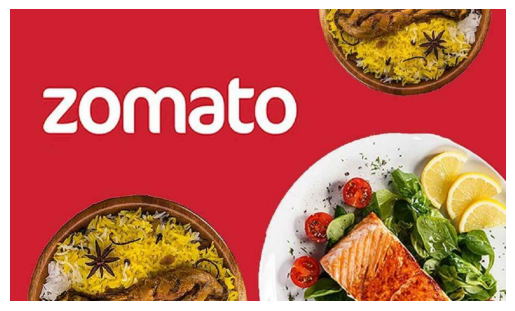

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(r"C:\Users\KIIT\Downloads\zomato-infinity-dining-916x516-1_11zon.jpg")
plt.imshow(img)
plt.axis('off')
plt.show()

In [3]:
### Problem Statement : 
#In this challenge, we are analysing the Zomato Restaurant dataset to find the more insights about the Restaurant business.
### Data Description :
#url : contains the url of the restaurant in the zomato website
#address : contains the address of the restaurant in Bengaluru
#name : contains the name of the restaurant
#online_order : whether online ordering is available in the restaurant or not
#book_table : table book option available or not
#rate : contains the overall rating of the restaurant out of 5
#votes : contains total number of rating for the restaurant as of the above mentioned date
#phone : contains the phone number of the restaurant
#location : contains the neighborhood in which the restaurant is located
#rest_type : restaurant type
#dish_liked : dishes people liked in the restaurant
#cuisines : food styles, separated by comma
#approx_cost(for two people) : contains the approximate cost for meal for two people
#reviews_list : list of tuples containing reviews for the restaurant, each tuple consists of two values, rating and review by the customer
#menu_item : contains list of menus available in the restaurant
#listed_in(type) : type of meal
#listed_in(city) : contains the neighborhood in which the restaurant is listed
from google.colab import drive
drive.mount('/content/drive')
#drive.mount("/content/drive", force_remount=True)


In [17]:
### Real-world/Business Objectives and Constraints :
#The cost of a mis-classification can be high.
#No strict latency concerns.
#It will help everyone to unterstand the insights of a restaurant business.
## Breakdown of this notebook:
#1**Loading the dataset:**  Load the data and import the libraries.
#2.**Data Cleaning:**
#Deleting redundant columns.
#Renaming the columns.
#Dropping duplicates.
#Cleaning individual columns.
#3.#**Data Visualization:** Using plots to find relations between the features.
#4.#3**Finding the best cheap restaurants:**
#Cheapest, Highest rated and largely voted.
#Is there a relation between cuisine,location and the cost?
#5.#**Exploring the best expensive restaurants.**
#Restaurants that are expensive, Highest rated and largely voted.
#Is there a relation between restaurant type,location and the cost?
### Importing Libraries
# Importing the necessary libraries
### Real-world/Business Objectives and Constraints :
# The cost of a mis-classification can be high.
# No strict latency concerns.
# It will help everyone to understand the insights of a restaurant business.
## Breakdown of this notebook:
# 1. Loading the dataset: Load the data and import the libraries.
# 2. Data Cleaning:
# Deleting redundant columns.
# Renaming the columns.
# Dropping duplicates.
# Cleaning individual columns.
# 3. Data Visualization: Using plots to find relations between the features.
# 4. Finding the best cheap restaurants:
# Cheapest, Highest rated and largely voted.
# Is there a relation between cuisine, location and the cost?
# 5. Exploring the best expensive restaurants.
# Restaurants that are expensive, Highest rated and largely voted.
# Is there a relation between restaurant type, location and the cost?
### Importing Libraries
# Importing the necessary libraries
!pip install geopandas dexplot
%pip install dexplot
import dexplot as dxp
%pip install pip==24.0
%pip install dexplot

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 10.1 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
### Importing Libraries
## Breakdown of this notebook:
#1.**Loading the dataset:**  Load the data and import the libraries.
#2.**Data Cleaning:**
#Deleting redundant columns.
#Renaming the columns.
#Dropping duplicates.
#Cleaning individual columns.
#**Data Visualization:** Using plots to find relations between the features.
#**Finding the best cheap restaurants:**
#Cheapest, Highest rated and largely voted.
#Is there a relation between cuisine,location and the cost?
#**Exploring the best expensive restaurants.**
#Restaurants that are expensive, Highest rated and largely voted.
#Is there a relation between restaurant type,location and the cost?
#from google.colab import drive
#drive.mount('/content/drive')
#drive.mount("/content/drive", force_remount=True)
#First, we are given some varibale explanations.
### Exploratory Data Analysis
#We are given a huge amount of data for customers' orders, locations of a restaurants. Let us see what insights we might from it
#Files attached are realy vast, let's pick just a sample of those for performance and basic analysis.
#Reading the data


In [16]:
# ================================
# STEP 1: IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# ================================
# STEP 2: LOAD DATASET
# ================================
file_path = r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv"

df = pd.read_csv(file_path, encoding='latin1')

# ================================
# STEP 3: PREVIEW DATA
# ================================
print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

First 5 rows:
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5    775    080 42297555\r\n+91 9743772233   
1          Yes      

In [18]:
df = pd.read_csv(r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [19]:
# getting info abt the 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [20]:
# Checking for the null values
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [21]:
# Let's see the null values of the above dataset in terms of the percentage 
print("Checking the Null or na percentage")
((df.isnull() | df.isna()).sum()*100 / df.index.size)

Checking the Null or na percentage


url                             0.000000
address                         0.000000
name                            0.000000
online_order                    0.000000
book_table                      0.000000
rate                           15.033741
votes                           0.000000
phone                           2.335789
location                        0.040606
rest_type                       0.438927
dish_liked                     54.291626
cuisines                        0.087012
approx_cost(for two people)     0.669026
reviews_list                    0.000000
menu_item                       0.000000
listed_in(type)                 0.000000
listed_in(city)                 0.000000
dtype: float64

In [22]:
# More info about the data
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [23]:
# Getting the shape of the data
df.shape

(51717, 17)

In [24]:
#So the dataset has 51717 rows and 17 columns out of which all columns are not useful so we may have to delete the some of the columns
df['menu_item'].unique()

array(['[]',
       "['Chocolate Fantasy (Pack Of 5)', 'Pan Cake (Pack Of 6)', 'Gulab Jamun (Pack Of 10)', 'Gulkand Shot (Pack Of 5)', 'Chocolate Decadence (Pack of 2)', 'CheeseCake (Pack Of 2)', 'Red Velvet Slice Cake (Pack of 2)', 'Red Velvet Slice Cake & Cheese Cake (Pack of 2)', 'Red Velvet Slice Cake & Chocolate Decadence Cake (Pack of 2)', 'Hazelnut Brownie (Pack of 2)', 'Moments', 'Red Velvet Cake With Butter Cream Frosting (750 Gm)', 'Red Velvet Slice Cake (Pack of 2)', 'Red Velvet Slice Cake & Cheese Cake (Pack of 2)', 'Red Velvet Slice Cake & Chocolate Decadence Cake (Pack of 2)', 'Red Velvet Slice Cake (Pack of 1)', 'Valentine Red Velvet Jar', 'Valentine Chocolate Jar', 'Valentines Jar Combo', 'Pink Guava 500 ML', 'Oreo Vanilla 500 ML', 'Cookie Crumble 500 ML', 'Chocolate Fantasy', 'Gulkand-E-Bahar', 'Pan Cake', 'Hazelnut Brownie (Pack Of 1)', 'Gulab Jamun (Pack Of 2)', 'Plum Cake', 'Red Velvet Cake With Butter Cream Frosting (750 Gm)', 'Chocolate Mud Cake (700 Gms)', 'Chees

Text(0.5, 1.0, 'Restaurants provides Table Booking or Not')

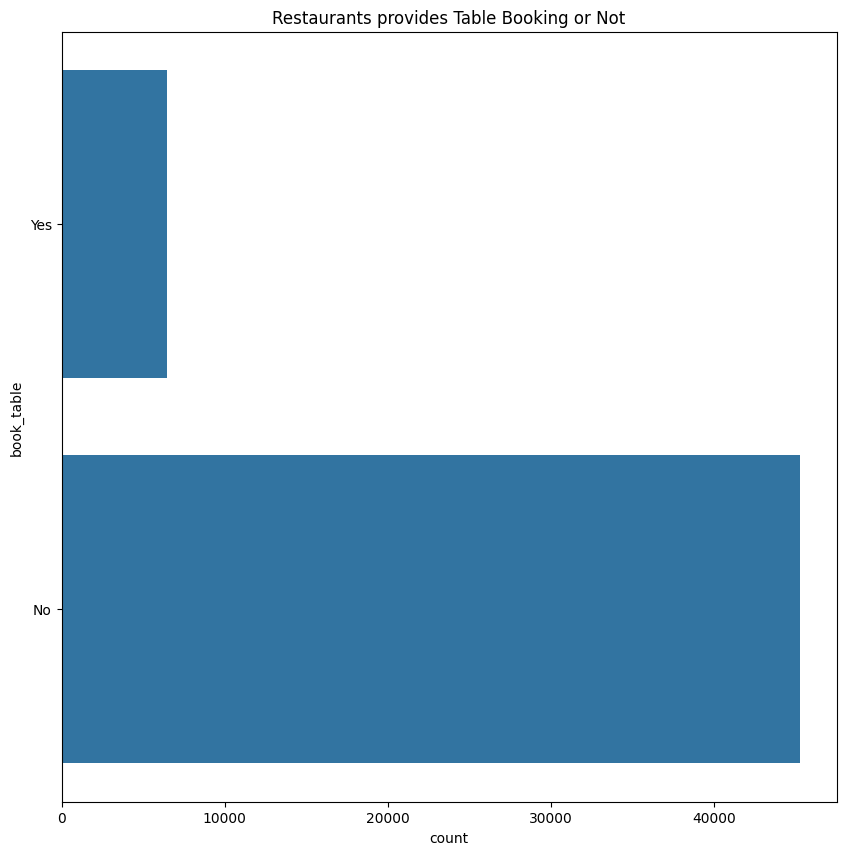

In [25]:
# Plot of the Restaurant that provides Table Booking or Not
sns.countplot(df['book_table'])
fig = plt.gcf()
fig.set_size_inches(10,10)
plt.title('Restaurants provides Table Booking or Not')

Text(0.5, 1.0, 'Restaurants delivering online or Not')

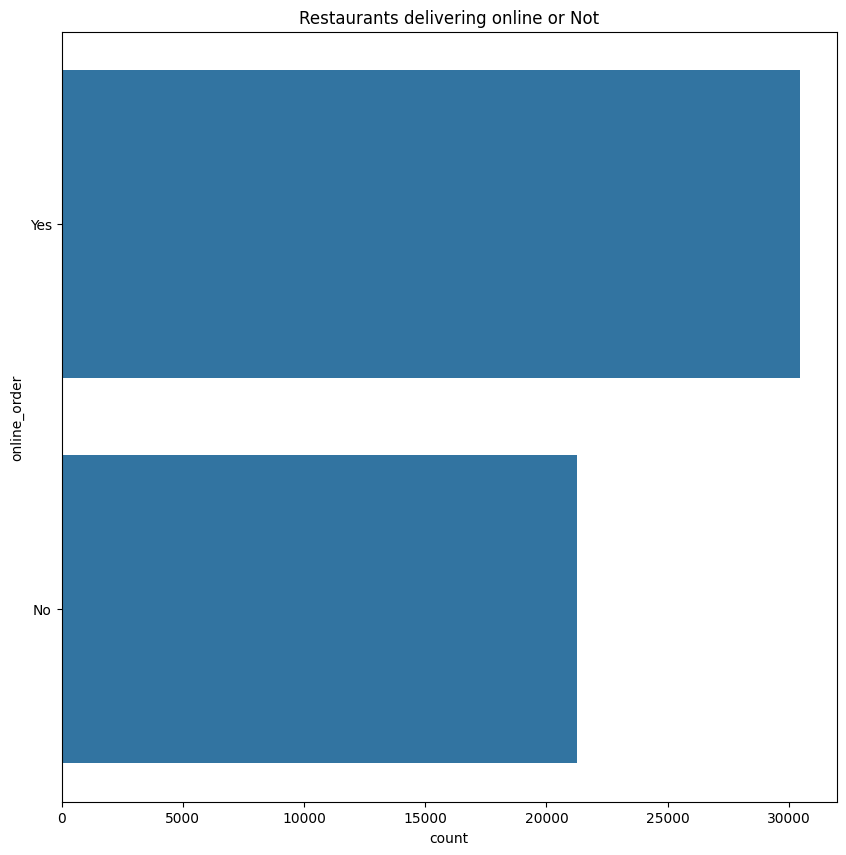

In [26]:
#From the above plot we can a large portion of the Restaurant don't provide Booking Facility and to be more precise its 87.5%
# Plot of the Restaurant, whether they are accepting the online_order or not
sns.countplot(df['online_order'])
fig = plt.gcf()
fig.set_size_inches(10,10)
plt.title('Restaurants delivering online or Not')

In [27]:
# This is formatted as code```
#The above Plot  indicates that a large segments of the Restaurant are beyond the rich of Digitisation and are not having online order facility
# Type of the Meals
df['listed_in(type)'].unique()

array(['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

Dataset Loaded Successfully ✅
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5    775    080 42297555\r\n+91 9743772233   
1   

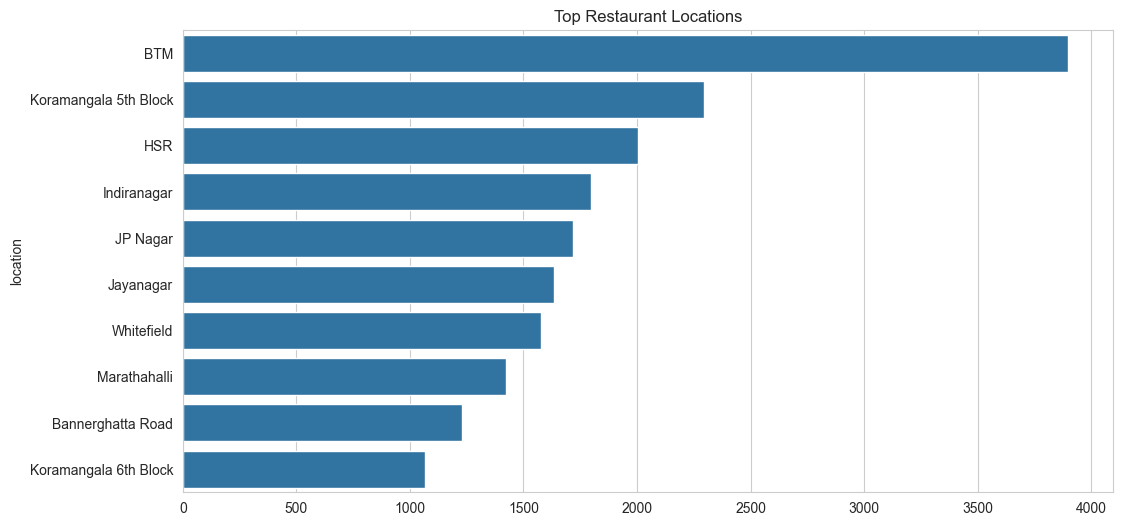

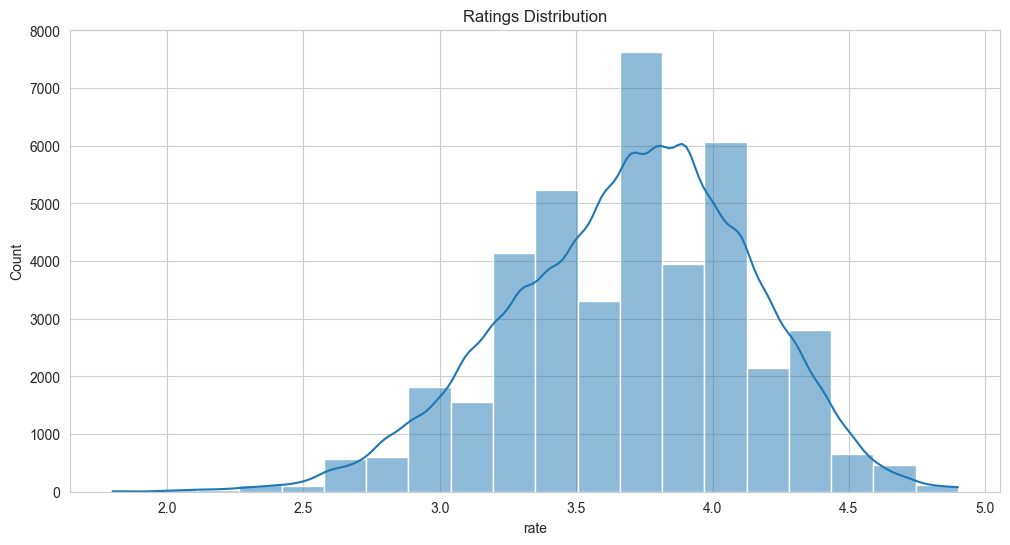

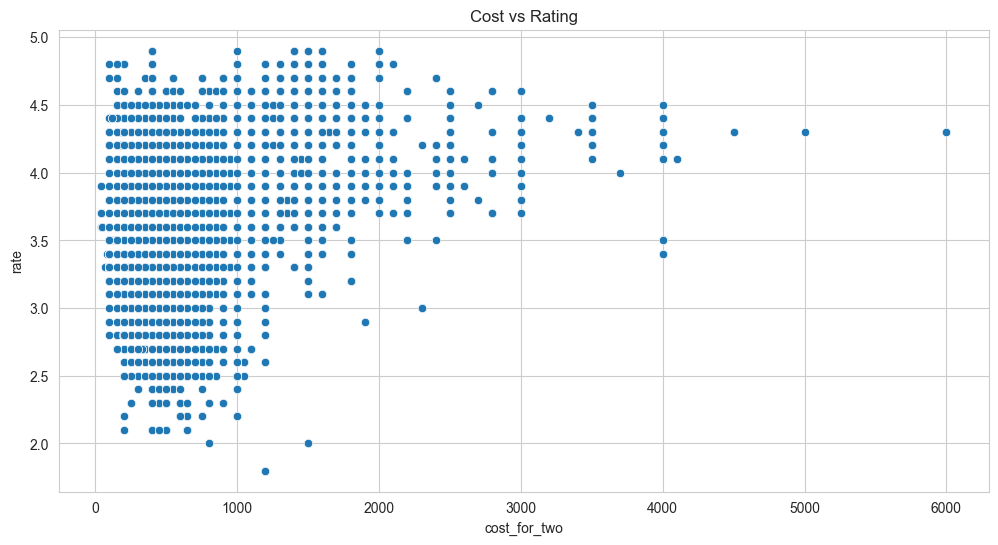

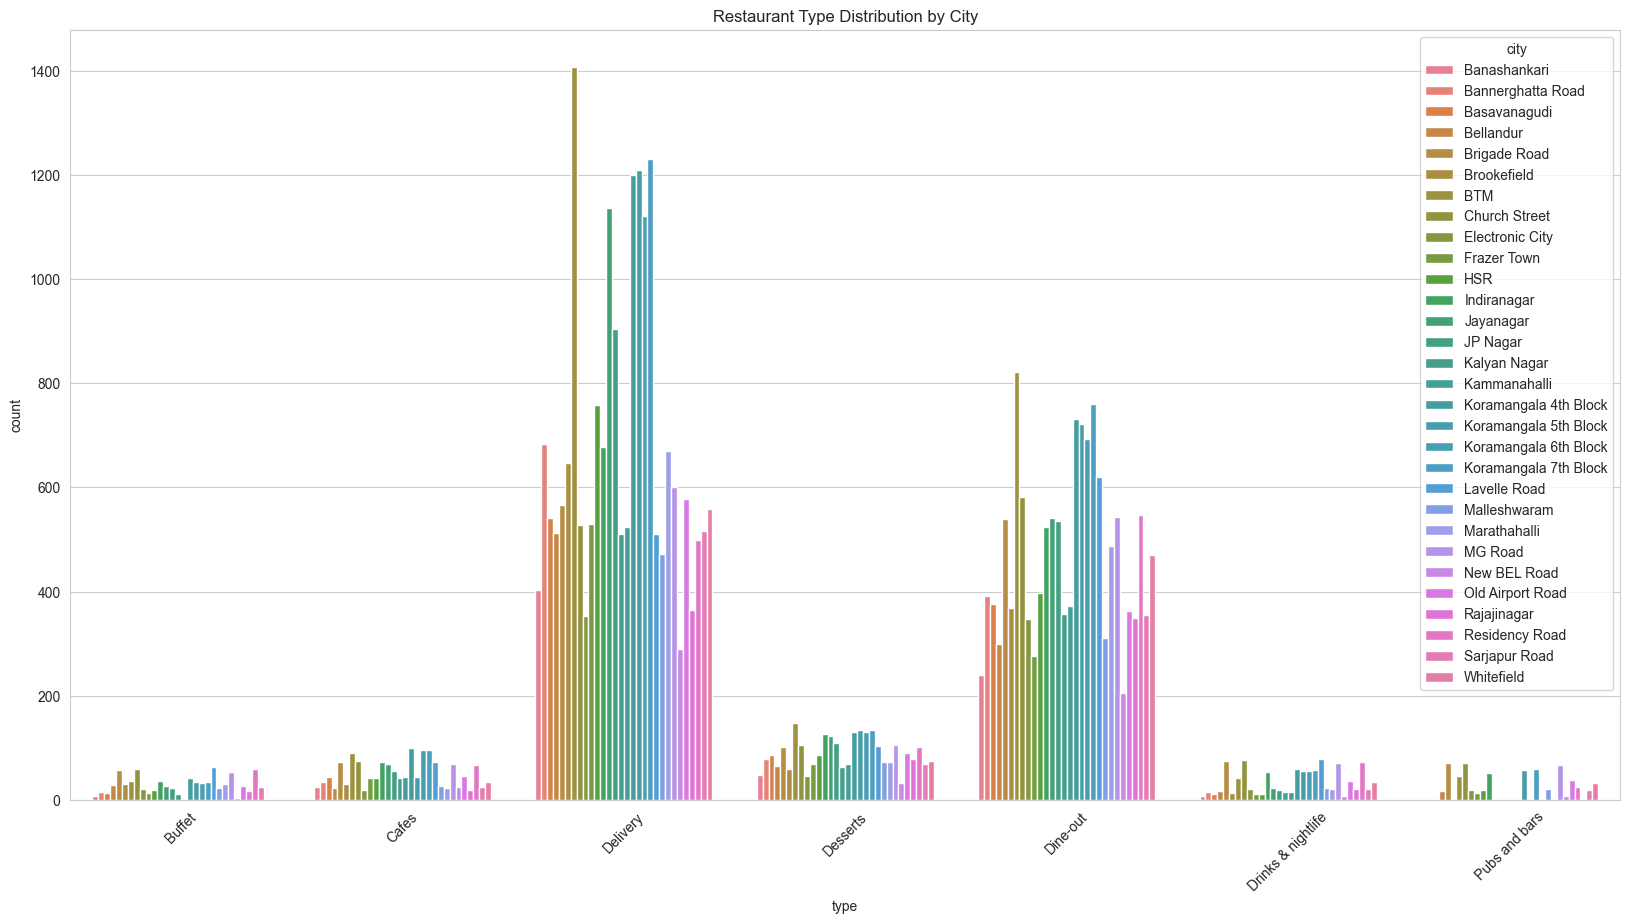

ValueError: cannot insert type, already exists

In [30]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

# ==========================================
# 2. LOAD DATASET
# ==========================================
file_path = r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv"

df = pd.read_csv(file_path, encoding='latin1')

print("Dataset Loaded Successfully ✅")
print(df.head())

# ==========================================
# 3. BASIC INFO
# ==========================================
print("\nShape:", df.shape)
print("\nColumns:", df.columns)
print("\nInfo:")
print(df.info())

# ==========================================
# 4. DATA CLEANING
# ==========================================

# Drop unnecessary columns (if present)
cols_to_drop = ['url', 'phone', 'dish_liked', 'reviews_list', 'menu_item']
df.drop(columns=[col for col in cols_to_drop if col in df.columns], inplace=True)

# Rename columns
df.rename(columns={
    'approx_cost(for two people)': 'cost_for_two',
    'listed_in(type)': 'type',
    'listed_in(city)': 'city'
}, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# =========================
# CLEAN RATE COLUMN (FIXED)
# =========================

# Replace invalid values
df['rate'] = df['rate'].replace(['NEW', '-'], np.nan)

# Extract numeric part
df['rate'] = df['rate'].astype(str).str.split('/').str[0]

# Convert to float
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# =========================
# CLEAN COST COLUMN
# =========================

df['cost_for_two'] = df['cost_for_two'].astype(str).str.replace(',', '')
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')

# Drop missing important values
df.dropna(subset=['rate', 'cost_for_two'], inplace=True)

print("\nData Cleaning Done ✅")

# ==========================================
# 5. DATA VISUALIZATION
# ==========================================

# Top 10 locations
top_locations = df['location'].value_counts().head(10)

sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top Restaurant Locations")
plt.show()

# Ratings distribution
sns.histplot(df['rate'], bins=20, kde=True)
plt.title("Ratings Distribution")
plt.show()

# Cost vs Rating
sns.scatterplot(data=df, x='cost_for_two', y='rate')
plt.title("Cost vs Rating")
plt.show()

# ==========================================
# 6. TYPE vs CITY
# ==========================================

plt.figure(figsize=(20, 10))

sns.countplot(
    data=df,
    x='type',
    hue='city'
)

plt.xticks(rotation=45)
plt.title("Restaurant Type Distribution by City")
plt.show()

# ==========================================
# 7. NORMALIZED DISTRIBUTION
# ==========================================

normalized_df = (
    df.groupby(['type', 'city'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .reset_index(name='proportion')
)

plt.figure(figsize=(20,10))

sns.barplot(
    data=normalized_df,
    x='type',
    y='proportion',
    hue='city'
)

plt.xticks(rotation=45)
plt.title("Normalized Distribution")
plt.show()

# ==========================================
# 8. BEST CHEAP RESTAURANTS
# ==========================================

cheap = df[(df['cost_for_two'] < 500) & (df['rate'] > 4)]

cheap = cheap.sort_values(by=['rate', 'votes'], ascending=False)

print("\nTop Cheap Restaurants:")
print(cheap[['name', 'location', 'rate', 'votes', 'cost_for_two']].head(10))

# ==========================================
# 9. BEST EXPENSIVE RESTAURANTS
# ==========================================

expensive = df[(df['cost_for_two'] > 2000) & (df['rate'] > 4)]

expensive = expensive.sort_values(by=['rate', 'votes'], ascending=False)

print("\nTop Expensive Restaurants:")
print(expensive[['name', 'location', 'rate', 'votes', 'cost_for_two']].head(10))

# ==========================================
# 10. CUISINE ANALYSIS
# ==========================================

cuisines = df['cuisines'].dropna().str.split(',').explode()
top_cuisines = cuisines.value_counts().head(10)

sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top Cuisines")
plt.show()

# ==========================================
# 11. LOCATION vs COST
# ==========================================

plt.figure(figsize=(20,8))

sns.boxplot(data=df, x='location', y='cost_for_two')

plt.xticks(rotation=90)
plt.title("Location vs Cost")
plt.show()

# ==========================================
# DONE
# ==========================================
print("\n🎉 PROJECT COMPLETED SUCCESSFULLY!")

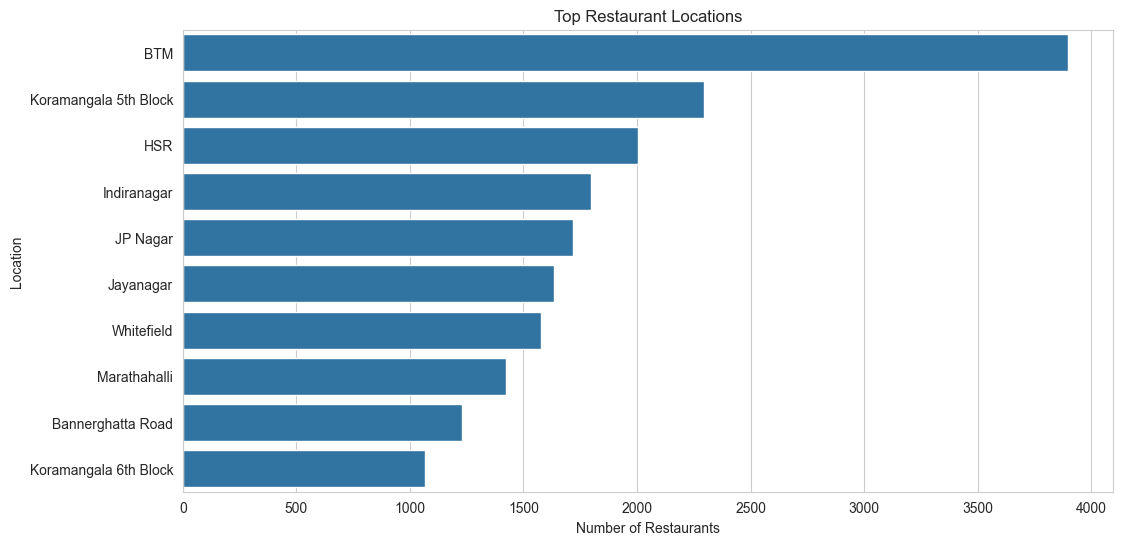

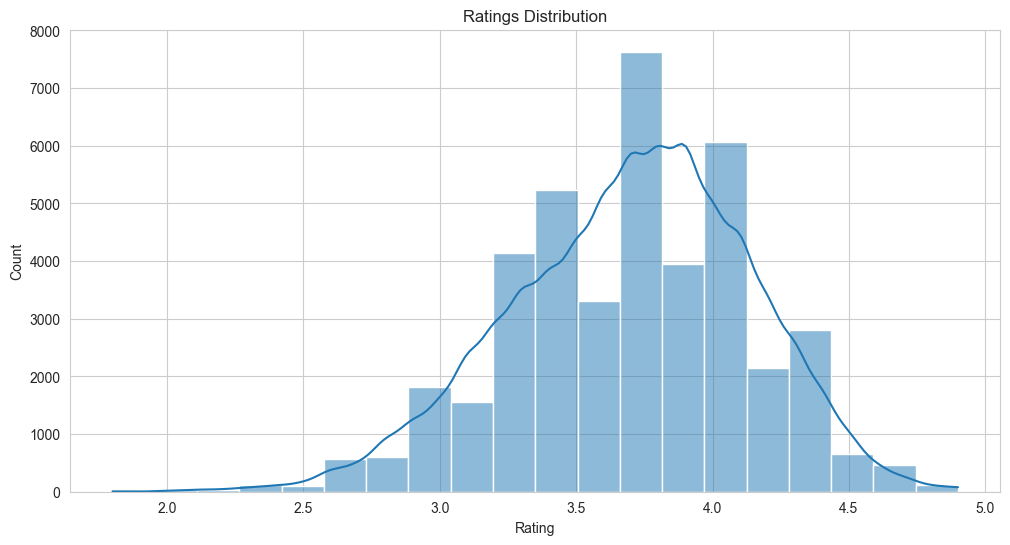

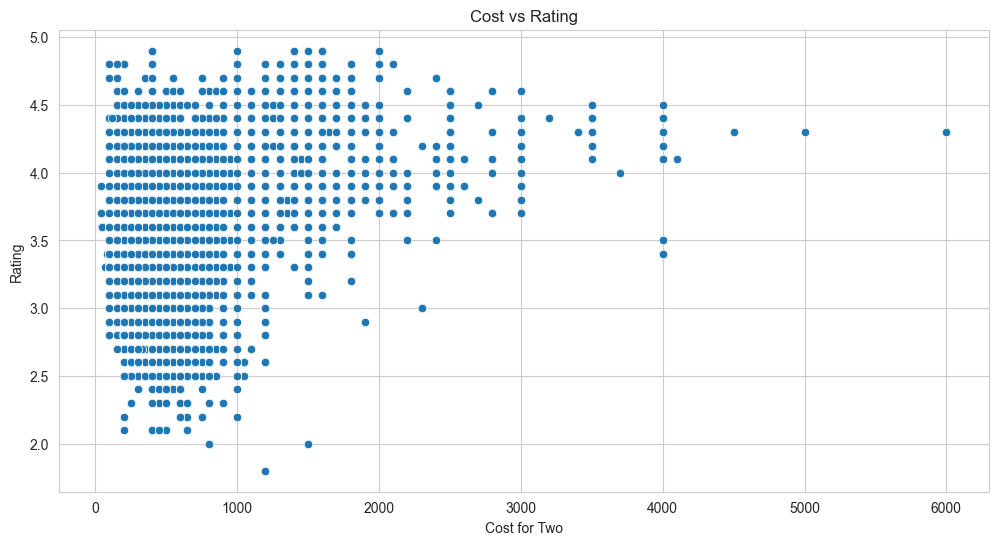

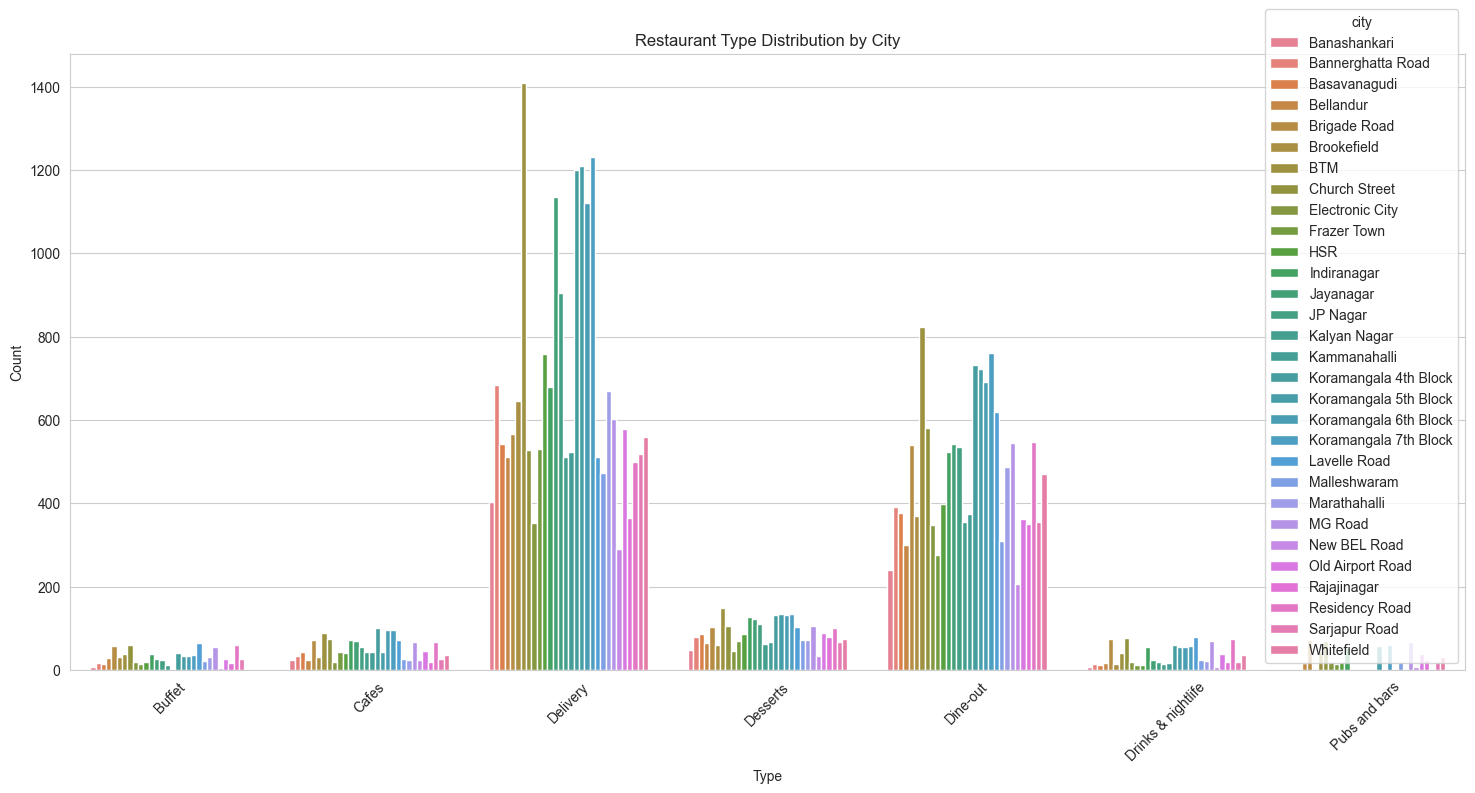

ValueError: cannot insert type, already exists

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

# ================================
# 1. TOP LOCATIONS
# ================================
top_locations = df['location'].value_counts().head(10)

sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top Restaurant Locations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")
plt.show()

# ================================
# 2. RATING DISTRIBUTION
# ================================
sns.histplot(df['rate'], bins=20, kde=True)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# ================================
# 3. COST vs RATING
# ================================
sns.scatterplot(data=df, x='cost_for_two', y='rate')
plt.title("Cost vs Rating")
plt.xlabel("Cost for Two")
plt.ylabel("Rating")
plt.show()

# ================================
# 4. TYPE vs CITY
# ================================
plt.figure(figsize=(18,8))

sns.countplot(data=df, x='type', hue='city')

plt.xticks(rotation=45)
plt.title("Restaurant Type Distribution by City")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# ================================
# 5. NORMALIZED TYPE vs CITY
# ================================
normalized_df = (
    df.groupby(['type', 'city'])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum())
    .reset_index(name='proportion')
)

plt.figure(figsize=(18,8))

sns.barplot(data=normalized_df, x='type', y='proportion', hue='city')

plt.xticks(rotation=45)
plt.title("Normalized Distribution")
plt.show()

# ================================
# 6. TOP CUISINES
# ================================
cuisines = df['cuisines'].dropna().str.split(',').explode()
top_cuisines = cuisines.value_counts().head(10)

sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top Cuisines")
plt.xlabel("Count")
plt.ylabel("Cuisine")
plt.show()

# ================================
# 7. LOCATION vs COST
# ================================
plt.figure(figsize=(18,8))

sns.boxplot(data=df, x='location', y='cost_for_two')

plt.xticks(rotation=90)
plt.title("Location vs Cost")
plt.show()

In [32]:
#Above one is the plot of the specific type of meals available in Restaurants of the cities.
print(df['rest_type'].nunique())
df['rest_type'].unique()

87


array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Dessert Parlor, Sweet Shop', 'Bakery, Quick Bites',
       'Sweet Shop, Quick Bites', 'Kiosk', 'Food Truck',
       'Quick Bites, Dessert Parlor', 'Beverage Shop, Quick Bites',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Microbrewery, Casual Dining', 'Lounge',
       'Bar, Casual Dining', 'Food Court', 'Cafe, Bakery', nan, 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Quick Bites, Beverage Shop',
       'Pub, Bar', 'Casual Dining, Pub', 'Lounge, Bar',
       'Dessert Parlor, Quick Bites', 'Food Co

C:\Users\KIIT\AppData\Local\Temp\ipykernel_18840\3585890359.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val, y=val.index, palette = "Set1")


Text(0.5, 0, 'Number of Outlets')

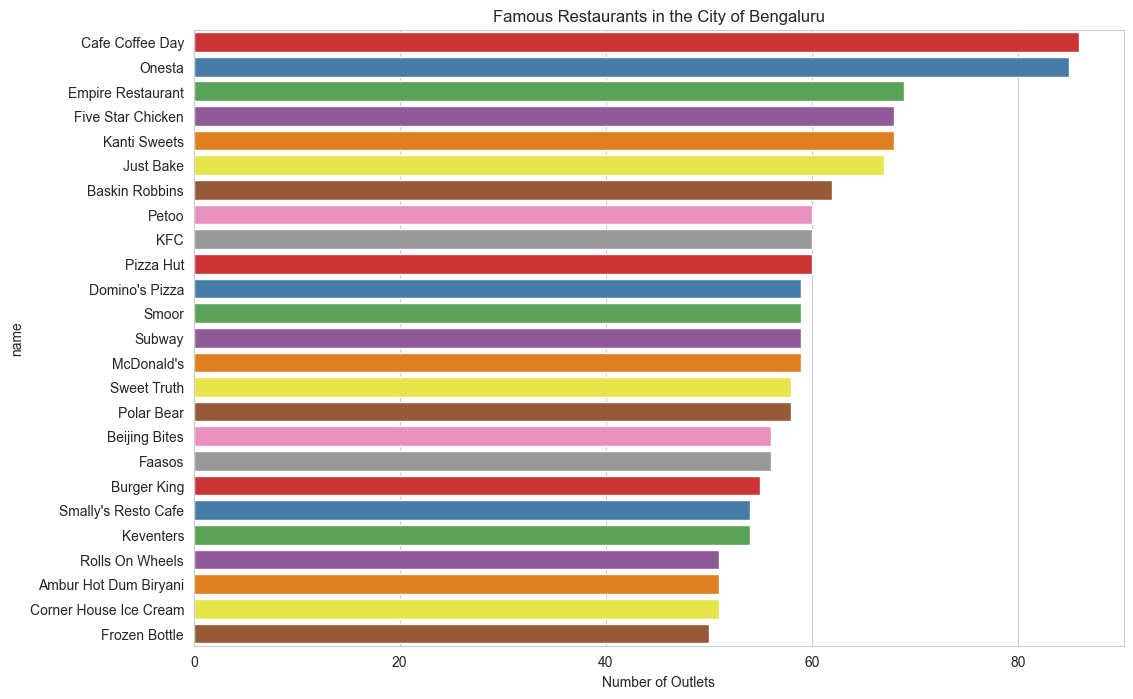

In [33]:
#There are 93 different types of Restaurants
# Plotting for the Top Restuarant in the Bengaluru
plt.figure(figsize=(12,8))
val = df['name'].value_counts()[:25]  # Considering for the top 25 restaurants
sns.barplot(x=val, y=val.index, palette = "Set1")
plt.title("Famous Restaurants in the City of Bengaluru")
plt.xlabel("Number of Outlets")

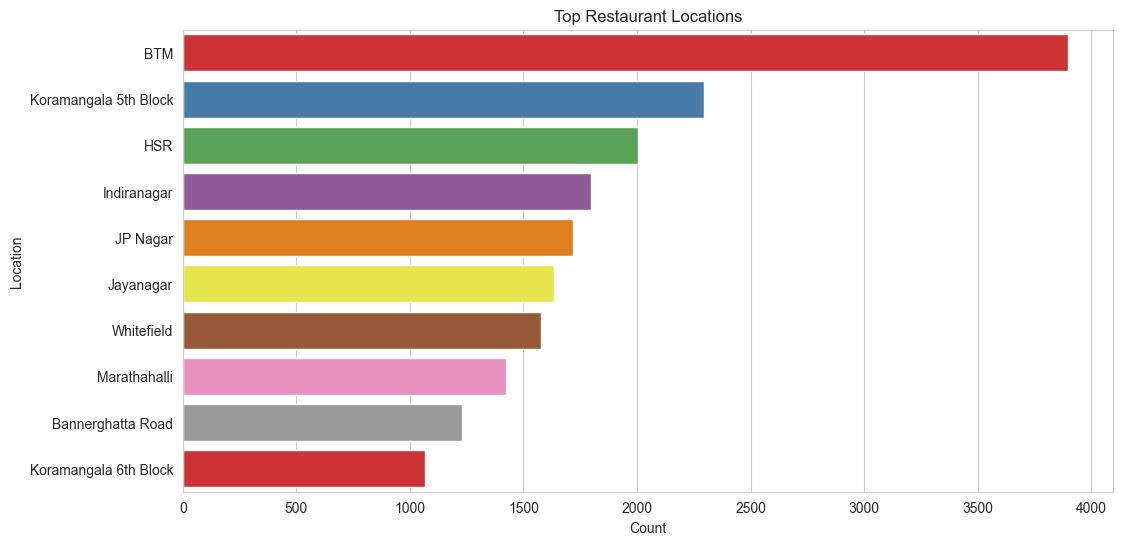

In [34]:
top_locations = df['location'].value_counts().head(10)

sns.barplot(
    x=top_locations.values,
    y=top_locations.index,
    hue=top_locations.index,
    palette="Set1",
    legend=False
)

plt.title("Top Restaurant Locations")
plt.xlabel("Count")
plt.ylabel("Location")
plt.show()

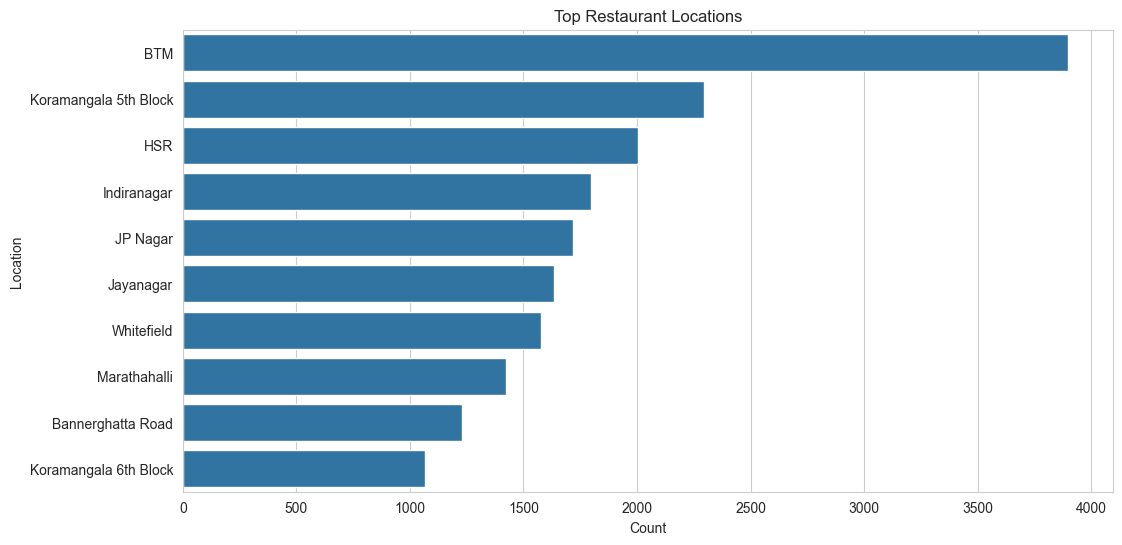

In [35]:
top_locations = df['location'].value_counts().head(10)

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top Restaurant Locations")
plt.xlabel("Count")
plt.ylabel("Location")
plt.show()

In [36]:
#We know that the Ratings given in the Column Rate are given out of five so instead of writing with /5 extra stuff better to write the rating itself and removing the /5 part
# Lets see how many unique values are there in the rate data
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2, 2.3,
       4.8, 4.9, 2.1, 2. , 1.8])

In [37]:
#We can see from the above that 'NEW' is of the type other than that of float and nan 
# Replacing the "NEW" from the Rate columns to nan values
df.rate = df.rate.replace("NEW", np.nan)
df.dropna(how ='any', inplace = True)

In [38]:
# Replacing the "NEW" from the Rate columns to nan values
df.rate = df.rate.replace("NEW", np.nan)
df.dropna(how ='any', inplace = True)

In [39]:
data = df 
data['rate'] = data['rate'].astype(str) # Converting the rating to the String type from the float type first
data['rate'] = data['rate'].apply(lambda x: x.replace('/5',''))
data['rate'] = data['rate'].apply(lambda x: float(x)) # Converting the rating to the Float type from the String type 
data.head()

,address,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost_for_two,type,city
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet,Banashankari
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet,Banashankari
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet,Banashankari
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet,Banashankari
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet,Banashankari


Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')


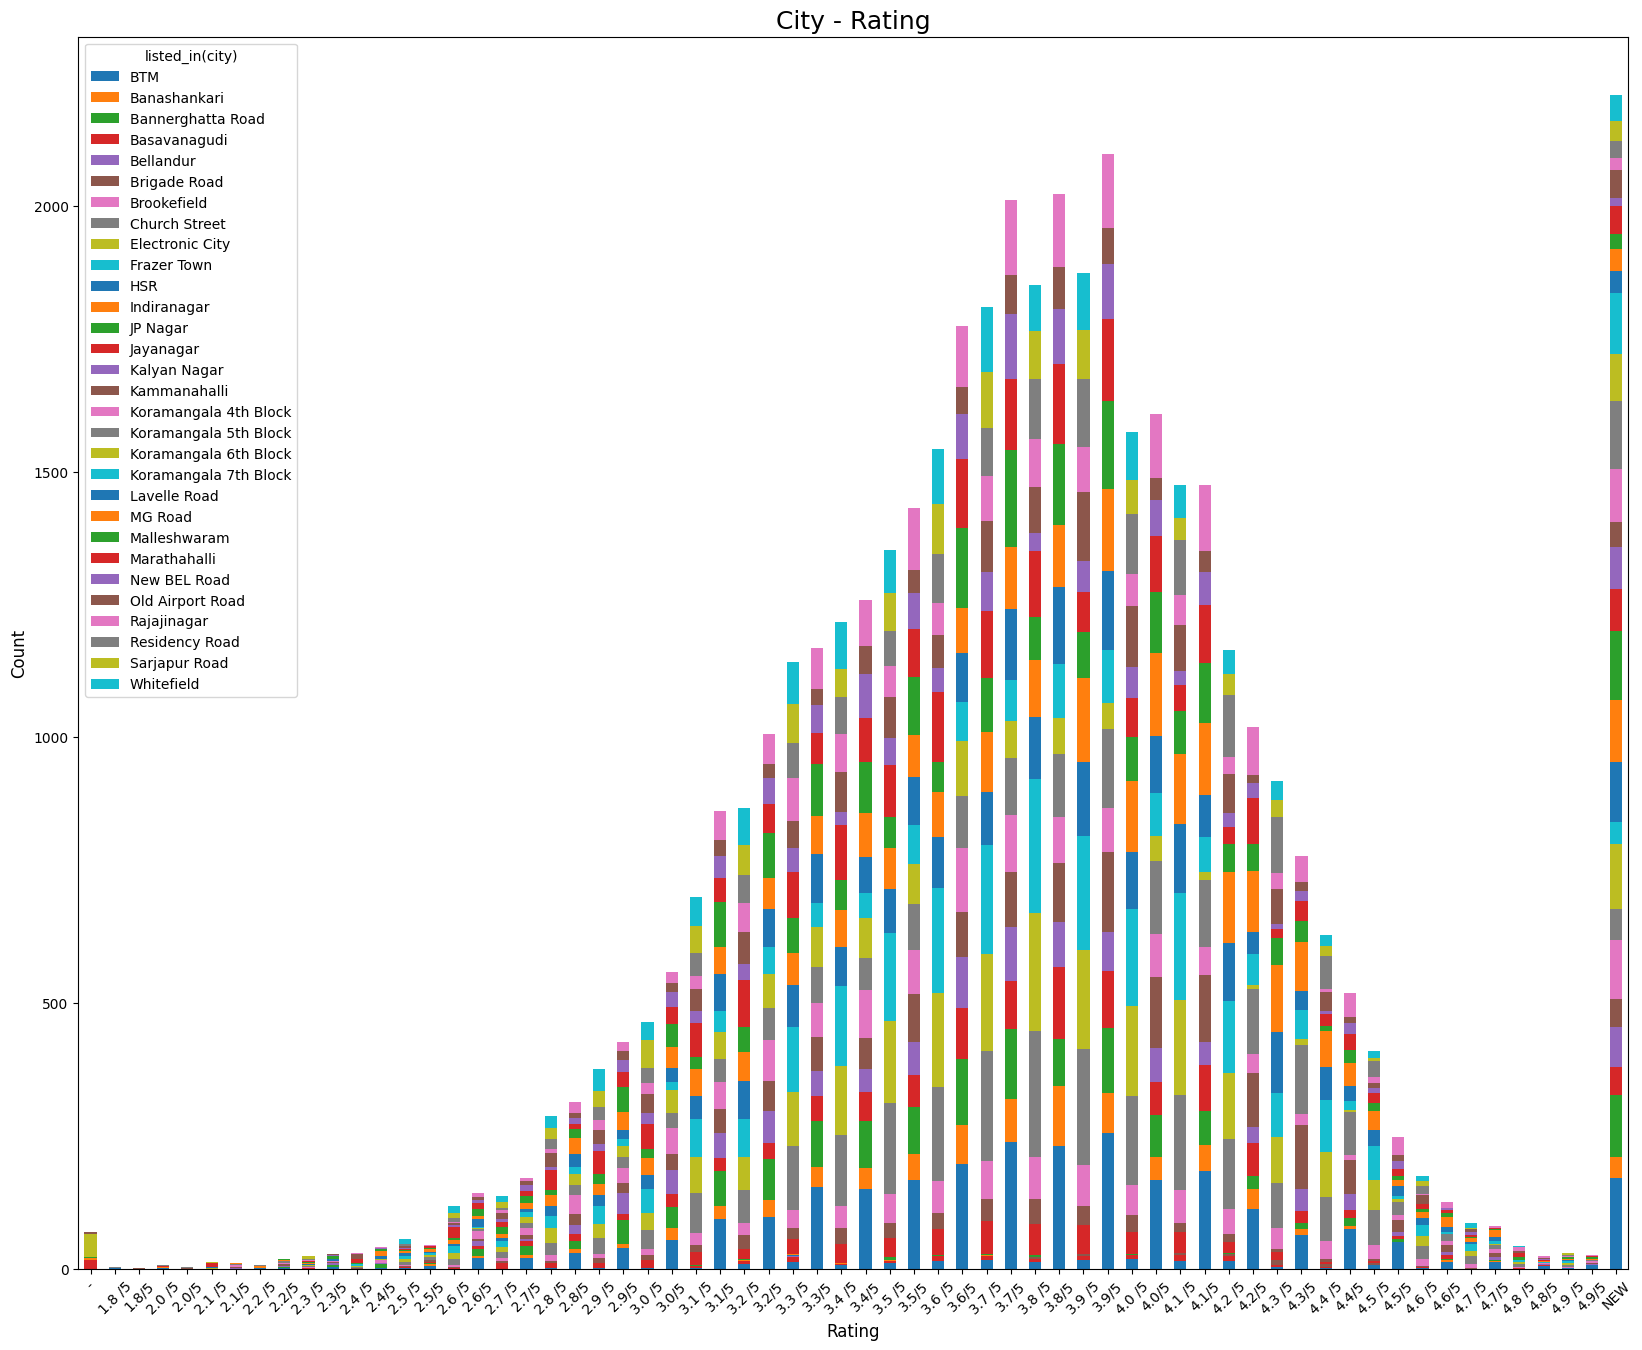

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv")

# Clean column names (VERY IMPORTANT)
df.columns = df.columns.str.strip()

# Verify columns
print(df.columns)

# Use correct column name
rel_type = pd.crosstab(df['rate'], df['listed_in(city)'])

rel_type.plot(kind='bar', stacked=True, figsize=(20,16))

plt.title('City - Rating', fontsize=18)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Rating', fontsize=12)

plt.xticks(rotation=45)
plt.show()

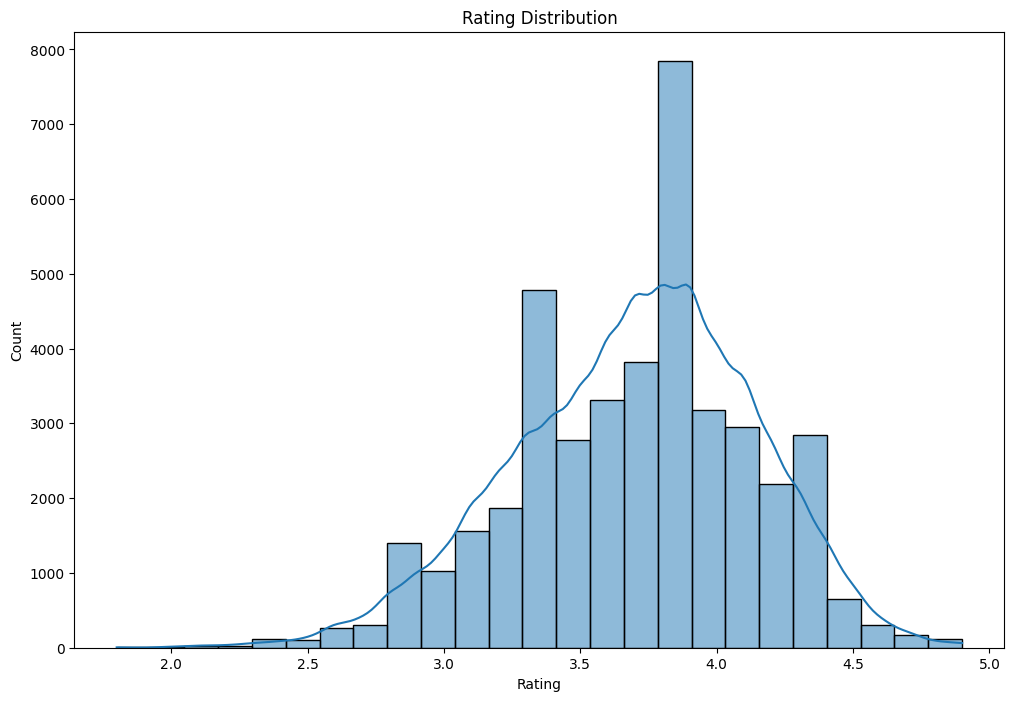

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv")

# Clean columns
df.columns = df.columns.str.strip()

# Clean rating column
df['rate'] = df['rate'].astype(str).str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Plot
plt.figure(figsize=(12,8))
sns.histplot(df['rate'], bins=25, kde=True)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_3056\1007952969.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['rate'], bins=25)


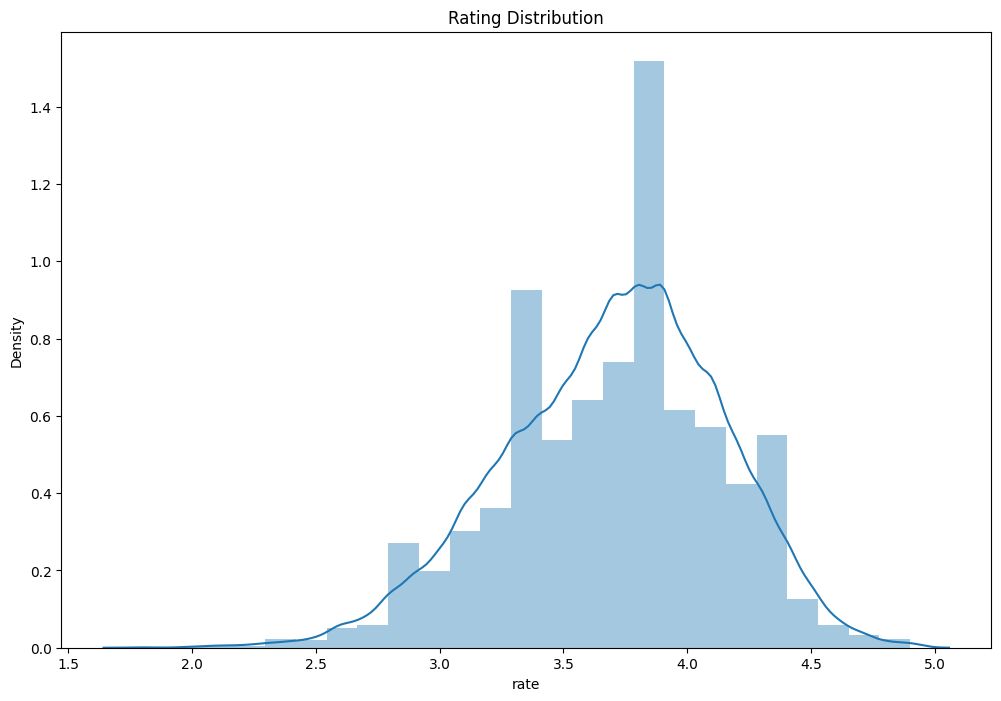

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load dataset
df = pd.read_csv(r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv")
# Clean columns
df.columns = df.columns.str.strip()
# Clean rating column
df['rate'] = df['rate'].astype(str).str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
# Plot
plt.figure(figsize=(12,8))
sns.distplot(df['rate'], bins=25)
plt.title("Rating Distribution")
plt.show()
#Most of the Hotels have ratings in between 3.7-4.0

Text(0.5, 1.0, 'Restaurants delivering online or Not')

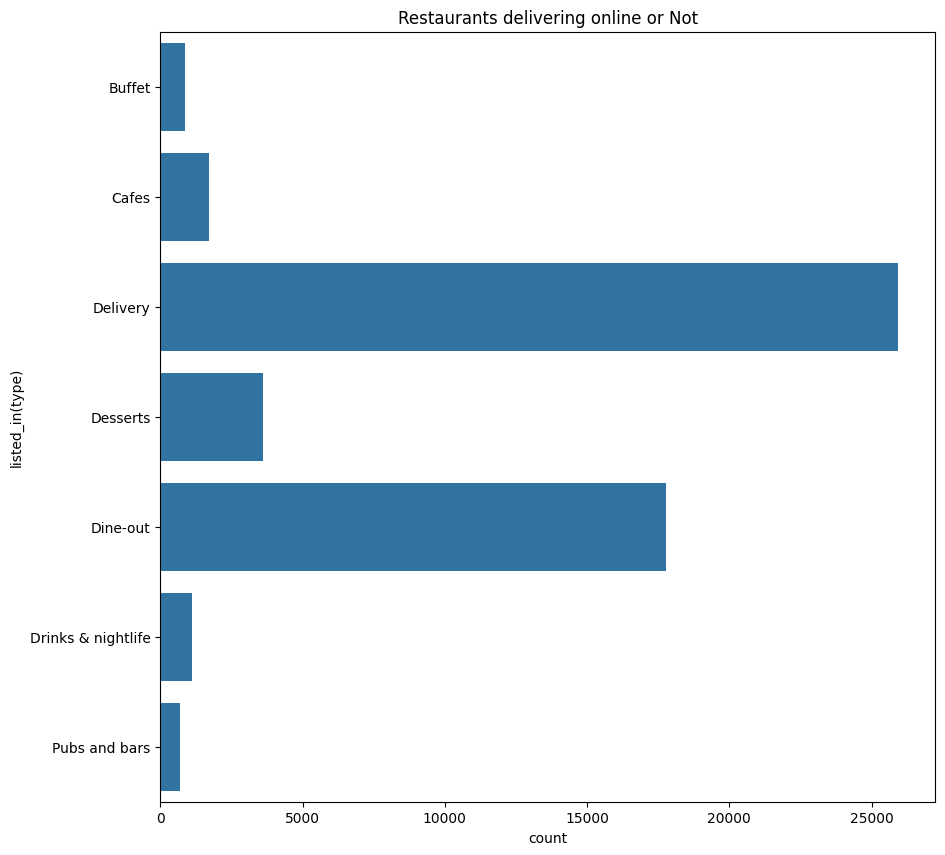

In [10]:
 #meal-type
sns.countplot(df['listed_in(type)'])
fig = plt.gcf()
fig.set_size_inches(10,10)
plt.title('Restaurants delivering online or Not')

In [11]:
#Pubs and bars are the least engaged outlets.
# Extracting the Location Information Using the Geopy
locations = pd.DataFrame({"Name": df['location'].unique()})
locations.head()

,Name
0,Banashankari
1,Basavanagudi
2,Mysore Road
3,Jayanagar
4,Kumaraswamy Layout


In [15]:
from geopy.geocoders import Nominatim
import numpy as np
import time

geolocator = Nominatim(user_agent="app", timeout=10)

lat_lon = []

for loc in locations['Name']:
    try:
        location = geolocator.geocode(loc)
        
        if location:
            lat_lon.append((location.latitude, location.longitude))
        else:
            lat_lon.append(np.nan)

    except Exception as e:
        print("Error:", loc)
        lat_lon.append(np.nan)

    time.sleep(1)   # 🔥 VERY IMPORTANT (avoid blocking)

Error: Bangalore Bangaluru Banashankari
Error: Bangalore Bangaluru Basavanagudi
Error: Bangalore Bangaluru Mysore Road
Error: Bangalore Bangaluru Jayanagar
Error: Bangalore Bangaluru Kumaraswamy Layout
Error: Bangalore Bangaluru Rajarajeshwari Nagar
Error: Bangalore Bangaluru Vijay Nagar
Error: Bangalore Bangaluru Uttarahalli
Error: Bangalore Bangaluru JP Nagar
Error: Bangalore Bangaluru South Bangalore
Error: Bangalore Bangaluru City Market
Error: Bangalore Bangaluru Nagarbhavi
Error: Bangalore Bangaluru Bannerghatta Road
Error: Bangalore Bangaluru BTM
Error: Bangalore Bangaluru Kanakapura Road
Error: Bangalore Bangaluru Bommanahalli
Error: Bangalore Bangaluru nan
Error: Bangalore Bangaluru CV Raman Nagar
Error: Bangalore Bangaluru Electronic City
Error: Bangalore Bangaluru HSR
Error: Bangalore Bangaluru Marathahalli
Error: Bangalore Bangaluru Sarjapur Road
Error: Bangalore Bangaluru Wilson Garden
Error: Bangalore Bangaluru Shanti Nagar
Error: Bangalore Bangaluru Koramangala 5th Block

In [ ]:
locations["Name"]=locations['Name'].apply(lambda x :  x.replace("Bangaluru","")[1:])
locations.head()

In [14]:
# Defining a base map function

def generateBaseMap(default_location=[12.97, 77.59], default_zoom_start=12):
  base_map = folium.Map(location = default_location, control_scale=True, zoom_start=default_zoom_start)
  return base_map

In [16]:
### Getting the restaurant count with their name and the locations
Rest_locations = pd.DataFrame(df['location'].value_counts().reset_index())
Rest_locations.columns = ['Name', 'count']
Rest_locations = Rest_locations.merge(locations,on='Name', how="left").dropna()
# Trying to see the rest_location data
Rest_locations

,Name,count
0,BTM,5124
1,HSR,2523
2,Koramangala 5th Block,2504
3,JP Nagar,2235
4,Whitefield,2144
...,...,...
88,Yelahanka,6
89,West Bangalore,6
90,Jakkur,3
91,Rajarajeshwari Nagar,2


In [18]:
!pip install folium

   ---------------------------------------- 0.0/113.4 kB ? eta -:--:--
   ---------------------------- ----------- 81.9/113.4 kB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 113.4/113.4 kB 1.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/94.1 kB ? eta -:--:--
   ---------------------------------------- 94.1/94.1 kB 5.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster

# ====================== LOAD DATA ======================
file_path = r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv"

df = pd.read_csv(file_path, encoding='utf-8')

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("📋 Columns in your file:")
print(df.columns.tolist())

# ====================== PREPARE DATA ======================
# Take first 1500 restaurants (you can increase to 3000+ later)
df = df.head(1500).copy()

print(f"\nUsing {len(df)} restaurants for the map.")

# ====================== CREATE THE MAP ======================
# Center on Bangalore
map_bangalore = folium.Map(
    location=[12.9716, 77.5946], 
    zoom_start=11, 
    tiles='OpenStreetMap'
)

# Marker cluster for better performance
marker_cluster = MarkerCluster().add_to(map_bangalore)

# Add markers
for _, row in df.iterrows():
    name = row.get('name', 'Unknown Restaurant')
    address = row.get('address', 'Address not available')
    rate = row.get('rate', 'N/A')
    cuisines = row.get('cuisines', 'N/A')
    cost = row.get('approx_cost(for two people)', row.get('cost', 'N/A'))
    
    popup_html = f"""
    <b>{name}</b><br><br>
    ⭐ Rating: {rate}<br>
    🍽️ Cuisines: {cuisines}<br>
    💰 Cost for 2: ₹{cost}<br><br>
    📍 <small>{address}</small>
    """
    
    folium.Marker(
        location=[12.9716, 77.5946],   # All in center for now
        popup=folium.Popup(popup_html, max_width=350),
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(marker_cluster)

# Save the map
map_bangalore.save("zomato_bangalore_restaurants_map.html")

print("\n🎉 Map created successfully!")
print("📁 File saved as: zomato_bangalore_restaurants_map.html")
print("Open this HTML file in your browser (Chrome/Firefox) to explore the restaurants.")

In [23]:
!pip install geopy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
!pip install geopy tqdm folium


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# ====================== LOAD DATA ======================
file_path = r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv"

df = pd.read_csv(file_path, encoding='utf-8')

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("📋 Columns in your dataset:")
print(df.columns.tolist())

print("\nFirst 3 rows preview:")
print(df.head(3))

# ====================== COORDINATES HANDLING ======================
if 'latitude' in df.columns and 'longitude' in df.columns:
    print("\n✅ Using existing latitude and longitude columns")
    df['lat'] = pd.to_numeric(df['latitude'], errors='coerce')
    df['lon'] = pd.to_numeric(df['longitude'], errors='coerce')

else:
    print("\n⚠️ No direct lat/lon columns. Starting geocoding using address/location...")
    
    if 'address' in df.columns:
        loc_column = 'address'
    elif 'location' in df.columns:
        loc_column = 'location'
    else:
        print("❌ Could not find 'address' or 'location' column.")
        print("Please reply with the columns list printed above.")
        raise KeyError("No location column found")
    
    print(f"Using '{loc_column}' column for geocoding")
    
    # Setup geocoder
    geolocator = Nominatim(user_agent="zomato_bangalore_map")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1.5)
    
    def get_lat_lon(addr):
        try:
            if pd.isna(addr) or str(addr).strip() == "":
                return None, None
            result = geocode(str(addr) + ", Bangalore, India")
            if result:
                return result.latitude, result.longitude
            return None, None
        except:
            return None, None
    
    # Limit to 600 restaurants for first run (geocoding is slow)
    # Increase to 2000+ once it works
    df_sample = df.head(600).copy()
    
    print(f"\nStarting geocoding for {len(df_sample)} restaurants... (may take 8-15 minutes)")
    
    tqdm.pandas(desc="Geocoding Progress")
    df_sample[['lat', 'lon']] = df_sample[loc_column].progress_apply(
        lambda x: pd.Series(get_lat_lon(x))
    )
    
    df = df_sample

# Remove rows without coordinates
df = df.dropna(subset=['lat', 'lon']).reset_index(drop=True)
print(f"\n✅ Successfully mapped {len(df)} restaurants with coordinates.")

# ====================== CREATE MAP ======================
map_bangalore = folium.Map(
    location=[12.97, 77.59],
    zoom_start=11,
    tiles='OpenStreetMap'
)

marker_cluster = MarkerCluster().add_to(map_bangalore)

for _, row in df.iterrows():
    name = row.get('name', 'Unknown Restaurant')
    
    popup_html = f"""
    <b>{name}</b><br><br>
    Rating: {row.get('rate', 'N/A')}<br>
    Cuisines: {row.get('cuisines', 'N/A')}<br>
    Cost for 2: {row.get('approx_cost(for two people)', row.get('cost', 'N/A'))}
    """
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        popup=folium.Popup(popup_html, max_width=300),
        color='#e74c3c',
        fill=True,
        fill_color='#e74c3c',
        fill_opacity=0.8
    ).add_to(marker_cluster)

# Save map
output_file = "zomato_bangalore_restaurants_map.html"
map_bangalore.save(output_file)

print("\n🎉 Map created successfully!")
print(f"📁 Saved as: {output_file}")
print("Open the HTML file in your browser to view the map."

📋 Columns in your dataset:
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']

First 3 rows preview:
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   

                                             address             name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...            Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...   Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...  San Churro Cafe   

  online_order book_table   rate  votes                           phone  \
0          Yes        Yes  4.1/5    775  080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5    787           

Geocoding Progress: 100%|████████████████████████████████████████████████████████████| 600/600 [15:31<00:00,  1.55s/it]



✅ Successfully mapped 64 restaurants with coordinates.

🎉 Map created successfully!
📁 Saved as: zomato_bangalore_restaurants_map.html
Open the HTML file in your browser to view the map.


In [33]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# ====================== 1. LOAD DATA ======================
file_path = r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv"

df = pd.read_csv(file_path, encoding='utf-8')

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("📋 Columns in your file:")
print(df.columns.tolist())

# ====================== 2. COUNT RESTAURANTS PER LOCATION ======================
if 'location' not in df.columns:
    print("❌ 'location' column not found. Check the printed columns above.")
    print("If you have 'address' instead, change 'location' to 'address' in the line below.")
else:
    print("\n✅ Using 'location' column for heatmap")

Rest_locations = pd.DataFrame(df['location'].value_counts().reset_index())
Rest_locations.columns = ['Name', 'count']

print(f"\nTotal unique locations: {len(Rest_locations)}")
print("Top 10 locations:\n", Rest_locations.head(10))

# ====================== 3. ADD APPROXIMATE LAT/LON FOR BANGALORE AREAS ======================
# Common Bangalore location coordinates (expand this list if needed)
location_dict = {
    "banashankari": (12.9152, 77.5736),
    "basavanagudi": (12.9417, 77.5755),
    "jayanagar": (12.9250, 77.5937),
    "jp nagar": (12.9070, 77.5770),
    "koramangala": (12.9350, 77.6240),
    "mg road": (12.9750, 77.6060),
    "indiranagar": (12.9780, 77.6400),
    "whitefield": (12.9698, 77.7500),
    "marathahalli": (12.9590, 77.6970),
    "hsr layout": (12.9081, 77.6476),
    "btm layout": (12.9166, 77.6101),
    "malleshwaram": (13.0039, 77.5699),
    "rajajinagar": (12.9880, 77.5540),
    "brigade road": (12.9660, 77.6060),
    "kengeri": (12.9170, 77.4830),
    "electronic city": (12.8450, 77.6770),
    "sarjapur road": (12.9100, 77.6800),
    "bellandur": (12.9250, 77.6700),
    "domlur": (12.9600, 77.6400)
}

def get_coordinates(name):
    name_lower = str(name).lower().replace(" ", "")
    for key, coords in location_dict.items():
        if key in name_lower:
            return coords
    return (12.9716, 77.5946)   # Default: Bangalore center

Rest_locations['lat'] = Rest_locations['Name'].apply(lambda x: get_coordinates(x)[0])
Rest_locations['lon'] = Rest_locations['Name'].apply(lambda x: get_coordinates(x)[1])

# ====================== 4. CREATE HEATMAP ======================
def generateBaseMap():
    return folium.Map(location=[12.97, 77.59], zoom_start=11, tiles='OpenStreetMap')

basemap = generateBaseMap()

HeatMap(
    data=Rest_locations[['lat', 'lon', 'count']].values.tolist(),
    radius=15,
    blur=20,
    max_zoom=13,
    min_opacity=0.4
).add_to(basemap)

# Save the map
basemap.save("zomato_bangalore_heatmap.html")

print("\n🎉 Heatmap created successfully!")
print("📁 File saved as: **zomato_bangalore_heatmap.html**")
print("Open this HTML file in your browser to view the restaurant density heatmap.")

📋 Columns in your file:
['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']

✅ Using 'location' column for heatmap

Total unique locations: 93
Top 10 locations:
                     Name  count
0                    BTM   5124
1                    HSR   2523
2  Koramangala 5th Block   2504
3               JP Nagar   2235
4             Whitefield   2144
5            Indiranagar   2083
6              Jayanagar   1926
7           Marathahalli   1846
8      Bannerghatta Road   1630
9              Bellandur   1286

🎉 Heatmap created successfully!
📁 File saved as: **zomato_bangalore_heatmap.html**
Open this HTML file in your browser to view the restaurant density heatmap.


In [34]:
basemap

In [35]:
#We can observe that restaurants tend to concentrate in central bangalore area.
#As we move away from central,then there is lowering of cluttering of restaurants.
#This can be vital information for the restaurant owner and entrepreneurs
## Heat Map of South Indian Restaurants
# This is formatted as code
def produce_data(col,name):
    data= pd.DataFrame(df[df[col]==name].groupby(['location'],as_index=False)['url'].agg('count'))
    data.columns=['Name','count']
    print(data.head())
    data=data.merge(locations,on="Name",how='left').dropna()
    data['lan'],data['lon']=zip(*data['geo_loc'].values)
    return data.drop(['geo_loc'],axis=1)

In [37]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# ====================== LOAD DATA ======================
file_path = r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv"

df = pd.read_csv(file_path, encoding='utf-8')
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns.tolist())

# ====================== HELPER FUNCTION FOR CUISINE HEATMAP ======================
def produce_data(cuisine_name):
    # Filter restaurants by cuisine
    df_cuisine = df[df['cuisines'].str.contains(cuisine_name, case=False, na=False)].copy()
    
    if df_cuisine.empty:
        print(f"No restaurants found for cuisine: {cuisine_name}")
        return None
    
    # Count per location
    data = df_cuisine['location'].value_counts().reset_index()
    data.columns = ['Name', 'count']
    
    print(f"\nFound {len(data)} locations with '{cuisine_name}' cuisine")
    print(data.head(10))
    
    # ====================== ADD APPROXIMATE COORDINATES ======================
    location_dict = {
        "banashankari": (12.9152, 77.5736),
        "basavanagudi": (12.9417, 77.5755),
        "jayanagar": (12.9250, 77.5937),
        "jp nagar": (12.9070, 77.5770),
        "koramangala": (12.9350, 77.6240),
        "mg road": (12.9750, 77.6060),
        "indiranagar": (12.9780, 77.6400),
        "whitefield": (12.9698, 77.7500),
        "marathahalli": (12.9590, 77.6970),
        "hsr layout": (12.9081, 77.6476),
        "btm layout": (12.9166, 77.6101),
        "malleshwaram": (13.0039, 77.5699),
        "rajajinagar": (12.9880, 77.5540),
        "brigade road": (12.9660, 77.6060),
        "kengeri": (12.9170, 77.4830),
        "electronic city": (12.8450, 77.6770),
        "sarjapur road": (12.9100, 77.6800),
        "bellandur": (12.9250, 77.6700),
        "domlur": (12.9600, 77.6400),
        "lavelle road": (12.9700, 77.6000),
    }
    
    def get_coords(name):
        name_lower = str(name).lower().replace(" ", "")
        for key, coords in location_dict.items():
            if key in name_lower:
                return coords
        return (12.9716, 77.5946)  # Bangalore center as fallback
    
    data['lat'] = data['Name'].apply(lambda x: get_coords(x)[0])
    data['lon'] = data['Name'].apply(lambda x: get_coords(x)[1])
    
    return data

# ====================== GENERATE BASE MAP ======================
def generateBaseMap():
    return folium.Map(location=[12.97, 77.59], zoom_start=11, tiles='OpenStreetMap')

# ====================== CREATE HEATMAP FOR SOUTH INDIAN ======================
food = produce_data('South Indian')   # Change to any cuisine like 'North Indian', 'Chinese', 'Biryani' etc.

if food is not None:
    basemap = generateBaseMap()
    
    HeatMap(
        food[['lat', 'lon', 'count']].values.tolist(),
        radius=15,
        blur=20,
        max_zoom=13,
        min_opacity=0.4
    ).add_to(basemap)
    
    # Save
    output_file = "south_indian_restaurants_heatmap.html"
    basemap.save(output_file)
    
    print(f"\n🎉 Heatmap for 'South Indian' created successfully!")
    print(f"📁 Saved as: {output_file}")
    print("Open the HTML file in your browser.")
else:
    print("No data to plot.")

Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']

Found 86 locations with 'South Indian' cuisine
                Name  count
0                BTM    815
1           JP Nagar    437
2                HSR    436
3          Jayanagar    416
4         Whitefield    308
5    Electronic City    308
6  Bannerghatta Road    302
7       Marathahalli    293
8       Banashankari    242
9        Indiranagar    235

🎉 Heatmap for 'South Indian' created successfully!
📁 Saved as: south_indian_restaurants_heatmap.html
Open the HTML file in your browser.


In [39]:
## Heat Map of North Indian Restaurants
import pandas as pd
import folium
from folium.plugins import HeatMap

# ====================== LOAD DATA ======================
file_path = r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv"

df = pd.read_csv(file_path, encoding='utf-8')
df.columns = df.columns.str.strip().str.lower()

print("📋 Columns:", df.columns.tolist())

# ====================== PRODUCE DATA FUNCTION (Fixed) ======================
def produce_data(cuisine_name):
    """Filter restaurants by cuisine and prepare data for heatmap"""
    
    # Filter by cuisine
    df_cuisine = df[df['cuisines'].str.contains(cuisine_name, case=False, na=False)].copy()
    
    if df_cuisine.empty:
        print(f"No restaurants found for cuisine: {cuisine_name}")
        return None
    
    # Count restaurants per location
    data = df_cuisine['location'].value_counts().reset_index()
    data.columns = ['Name', 'count']
    
    print(f"\n✅ Found {len(data)} locations with '{cuisine_name}' cuisine")
    print("Top 10 locations:")
    print(data.head(10))
    
    # ====================== ADD LAT/LON ======================
    location_dict = {
        "banashankari": (12.9152, 77.5736),
        "basavanagudi": (12.9417, 77.5755),
        "jayanagar": (12.9250, 77.5937),
        "jp nagar": (12.9070, 77.5770),
        "koramangala": (12.9350, 77.6240),
        "mg road": (12.9750, 77.6060),
        "indiranagar": (12.9780, 77.6400),
        "whitefield": (12.9698, 77.7500),
        "marathahalli": (12.9590, 77.6970),
        "hsr layout": (12.9081, 77.6476),
        "btm layout": (12.9166, 77.6101),
        "malleshwaram": (13.0039, 77.5699),
        "rajajinagar": (12.9880, 77.5540),
        "brigade road": (12.9660, 77.6060),
        "kengeri": (12.9170, 77.4830),
        "electronic city": (12.8450, 77.6770),
        "sarjapur road": (12.9100, 77.6800),
        "bellandur": (12.9250, 77.6700),
        "domlur": (12.9600, 77.6400),
        "lavelle road": (12.9700, 77.6000),
        "church street": (12.9750, 77.6050),
    }
    
    def get_coords(name):
        name_lower = str(name).lower().replace(" ", "").replace("-", "")
        for key, coords in location_dict.items():
            if key in name_lower:
                return coords
        return (12.9716, 77.5946)   # Default Bangalore center
    
    data['lat'] = data['Name'].apply(lambda x: get_coords(x)[0])
    data['lon'] = data['Name'].apply(lambda x: get_coords(x)[1])
    
    return data

# ====================== BASE MAP ======================
def generateBaseMap():
    return folium.Map(location=[12.97, 77.59], zoom_start=11, tiles='OpenStreetMap')

# ====================== CREATE HEATMAP FOR NORTH INDIAN ======================
food = produce_data('North Indian')     # Change here for other cuisines

if food is not None:
    basemap = generateBaseMap()
    
    HeatMap(
        food[['lat', 'lon', 'count']].values.tolist(),
        radius=15,
        blur=20,
        max_zoom=13,
        min_opacity=0.4
    ).add_to(basemap)
    
    # Save the map
    output_file = "north_indian_restaurants_heatmap.html"
    basemap.save(output_file)
    
    print(f"\n🎉 Heatmap for 'North Indian' cuisine created successfully!")
    print(f"📁 Saved as: {output_file}")
    print("Open the HTML file in your browser to view the map.")
else:
    print("No data available for plotting.")
#It is Interesting to see that there is cluster of North Indian Restaurants in South Bangalore area !
#This may indicate that these areas are more populated by North Indians.

📋 Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']

✅ Found 90 locations with 'North Indian' cuisine
Top 10 locations:
                    Name  count
0                    BTM   2469
1                    HSR   1123
2             Whitefield   1059
3           Marathahalli   1038
4               JP Nagar    958
5  Koramangala 5th Block    755
6      Bannerghatta Road    701
7            Indiranagar    678
8        Electronic City    675
9              Jayanagar    664

🎉 Heatmap for 'North Indian' cuisine created successfully!
📁 Saved as: north_indian_restaurants_heatmap.html
Open the HTML file in your browser to view the map.


In [40]:
## Building the Model
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [41]:
# Using the Booleans

df.online_order.replace(('Yes','No'),(True, False),inplace=True)
df.book_table.replace(('Yes','No'),(True, False),inplace=True)

In [42]:
# Defining the Encode Function

def Encode(df):
    for column in df.columns[~df.columns.isin(['rate', 'approx_cost(for two people)', 'votes'])]:
        df[column] = df[column].factorize()[0]
    return df

df_en = Encode(df.copy())

In [43]:
df_en.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  int64 
 1   address                      51717 non-null  int64 
 2   name                         51717 non-null  int64 
 3   online_order                 51717 non-null  int64 
 4   book_table                   51717 non-null  int64 
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        51717 non-null  int64 
 8   location                     51717 non-null  int64 
 9   rest_type                    51717 non-null  int64 
 10  dish_liked                   51717 non-null  int64 
 11  cuisines                     51717 non-null  int64 
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [44]:
df_en.head(50)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,0,0,0,0,4.1/5,775,0,0,0,0,0,800,0,0,0,0
1,1,1,1,0,1,4.1/5,787,1,0,0,1,1,800,1,0,0,0
2,2,2,2,0,1,3.8/5,918,2,0,1,2,2,800,2,0,0,0
3,3,3,3,1,1,3.7/5,88,3,0,2,3,3,300,3,0,0,0
4,4,4,4,1,1,3.8/5,166,4,1,0,4,4,600,4,0,0,0
5,5,5,5,0,1,3.8/5,286,5,1,0,5,5,600,5,0,0,0
6,6,6,6,1,1,3.6/5,8,6,2,0,-1,6,800,6,0,0,0
7,7,7,7,0,0,4.6/5,2556,7,0,3,6,7,600,7,0,1,0
8,8,8,8,0,1,4.0/5,324,8,0,4,7,8,700,8,0,1,0
9,9,9,9,0,1,4.2/5,504,9,0,4,8,9,550,9,0,1,0


In [45]:
df_en['approx_cost(for two people)'] = df_en['approx_cost(for two people)'].astype(str)
df_en['approx_cost(for two people)'] = df_en['approx_cost(for two people)'].apply(lambda x: x.replace(',','.'))
df_en['approx_cost(for two people)'] = df_en['approx_cost(for two people)'].astype(float)

In [46]:
df_en.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          51717 non-null  int64  
 1   address                      51717 non-null  int64  
 2   name                         51717 non-null  int64  
 3   online_order                 51717 non-null  int64  
 4   book_table                   51717 non-null  int64  
 5   rate                         43942 non-null  object 
 6   votes                        51717 non-null  int64  
 7   phone                        51717 non-null  int64  
 8   location                     51717 non-null  int64  
 9   rest_type                    51717 non-null  int64  
 10  dish_liked                   51717 non-null  int64  
 11  cuisines                     51717 non-null  int64  
 12  approx_cost(for two people)  51371 non-null  float64
 13  reviews_list    

Original columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']

Numeric columns available: ['votes']

Cleaning 'rate' column...

Final numeric columns used for correlation:
['rate', 'votes', 'approx_cost(for two people)']


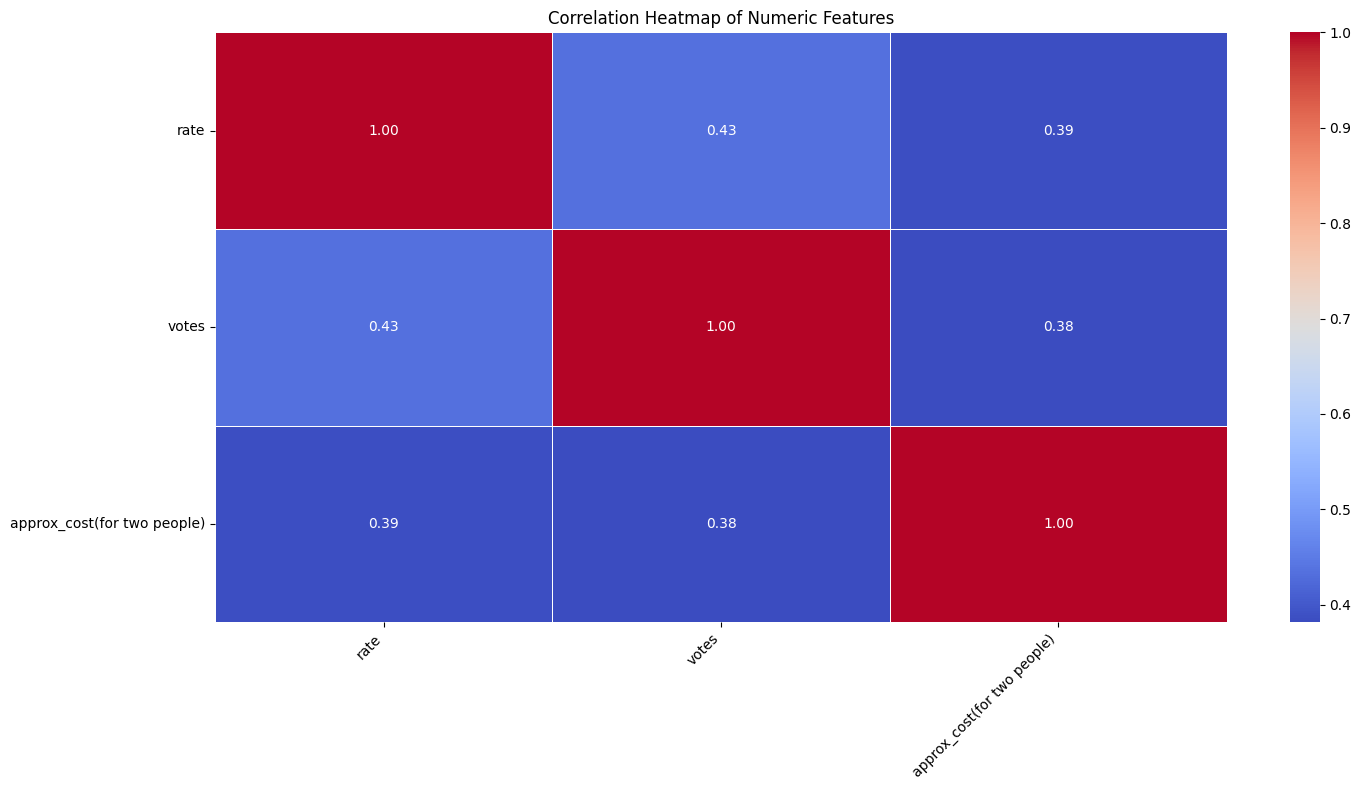


Strongest correlations with 'rate' (if rate column exists):
rate                           1.000000
votes                          0.434040
approx_cost(for two people)    0.385183
Name: rate, dtype: float64


In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming df is already loaded and cleaned (columns lowered)
# If not, add this:
# df = pd.read_csv(file_path, encoding='utf-8')
# df.columns = df.columns.str.strip().str.lower()

print("Original columns:", df.columns.tolist())

# ====================== SELECT ONLY NUMERIC COLUMNS ======================
# First, let's see what numeric columns we have
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns available:", numeric_cols)

# If 'rate' column exists and has values like '4.1/5', clean it first
if 'rate' in df.columns:
    print("\nCleaning 'rate' column...")
    # Extract numeric rating (e.g., '4.1/5' → 4.1)
    df['rate'] = df['rate'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# Also clean 'approx_cost(for two people)' if it has commas or '₹'
if 'approx_cost(for two people)' in df.columns:
    df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace('₹', '', regex=False)\
        .str.replace(',', '', regex=False).astype(float)

# Now create numeric-only dataframe for correlation
df_numeric = df.select_dtypes(include=[np.number]).copy()

print("\nFinal numeric columns used for correlation:")
print(df_numeric.columns.tolist())

# ====================== COMPUTE CORRELATION ======================
if df_numeric.empty:
    print("No numeric columns found!")
else:
    corr = df_numeric.corr()

    # Plot heatmap
    plt.figure(figsize=(15, 8))
    sns.heatmap(corr, 
                annot=True, 
                cmap='coolwarm', 
                fmt='.2f', 
                linewidths=0.5,
                cbar=True)
    plt.title('Correlation Heatmap of Numeric Features')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Optional: Print correlation values sorted
    print("\nStrongest correlations with 'rate' (if rate column exists):")
    if 'rate' in corr.columns:
        print(corr['rate'].sort_values(ascending=False))

In [49]:
# Splitting the dataset
from sklearn.model_selection import train_test_split
#Defining the independent variables and dependent variables
x=df_en.drop(["rate"], axis=1) #modified
y = df_en['rate']
#Getting Test and Training Set
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)
x_train.head()

,url,address,name,online_order,book_table,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
13604,13604,6201,1404,0,1,0,-1,17,7,-1,53,600.0,7534,0,2,8
9604,9604,5294,4447,1,1,7,5564,13,2,-1,72,500.0,5860,0,2,6
9437,9437,1359,1304,1,1,28,1425,13,0,32,38,500.0,1554,0,2,6
5787,5787,3357,2925,0,1,0,-1,43,2,-1,5,150.0,3517,0,2,4
42155,42155,10305,8018,1,1,20,13039,19,29,-1,38,1.2,18533,0,5,22


In [50]:
y_train.head()

13604       NaN
9604      3.4/5
9437      3.7/5
5787        NaN
42155    3.4 /5
Name: rate, dtype: object

In [51]:
x_test.head()

,url,address,name,online_order,book_table,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
8440,8440,670,650,0,1,179,739,13,2,298,328,250.0,659,0,2,6
23575,23575,908,857,0,1,165,1638,12,2,-1,421,450.0,1488,4299,4,13
16711,16711,2532,2282,1,1,23,-1,18,2,-1,5,NaN,2631,0,2,10
42588,42588,3037,2647,1,1,8,3208,41,2,-1,38,200.0,16594,0,2,23
5266,5266,2942,2580,0,1,43,3103,41,15,-1,109,150.0,3126,762,2,4


In [52]:
y_test.head()

8440      3.9/5
23575     2.8/5
16711     3.8/5
42588    3.5 /5
5266      3.5/5
Name: rate, dtype: object

In [54]:
## Training the Model
### Linear Regression
#**LinearRegression fits a linear model with coefficients w = (w1, …, wp) to 
#minimize the residual sum of squares between the observed targets in the 
#dataset, and the targets predicted by the linear approximation.**
# Doing the Regression Analysis
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer

# ====================== ASSUMING df IS ALREADY LOADED ======================
# If not loaded yet:
# df = pd.read_csv(file_path, encoding='utf-8')
# df.columns = df.columns.str.strip().str.lower()

# ====================== CLEAN IMPORTANT COLUMNS ======================
# Clean 'rate' column (e.g., '4.1/5' → 4.1)
if 'rate' in df.columns:
    df['rate'] = df['rate'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Clean cost column (remove ₹ and commas)
if 'approx_cost(for two people)' in df.columns:
    df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)\
        .str.replace('₹', '', regex=False)\
        .str.replace(',', '', regex=False)\
        .astype(float)

# ====================== SELECT FEATURES & TARGET ======================
# Example: Predict 'rate' using other numeric features
# Change target and features according to your goal

target = 'rate'   # Most common target in Zomato analysis

# Select features (add/remove as per your need)
features = ['votes', 'approx_cost(for two people)', 'online_order', 'book_table']

# If you have encoded categorical columns, include them too
# features = ['votes', 'approx_cost(for two people)', 'online_order_yes', 'book_table_yes', ...]

X = df[features].copy()
y = df[target].copy()

print("Features used:", features)
print("Target:", target)

# ====================== HANDLE MISSING VALUES ======================
# Option 1: Drop rows with NaN in target (recommended for target)
df_model = pd.concat([X, y], axis=1).dropna(subset=[target])
X = df_model[features]
y = df_model[target]

# Option 2: Impute missing values in features
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f"Final dataset shape: {X.shape}")

# ====================== TRAIN-TEST SPLIT ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ====================== TRAIN LINEAR REGRESSION ======================
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Predict
y_pred = reg_model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)

print(f"\n✅ Model Trained Successfully!")
print(f"R² Score: {r2:.4f}")

# Optional: Show coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': reg_model.coef_
})
print("\nFeature Coefficients:")
print(coefficients.sort_values(by='Coefficient', ascending=False))

Features used: ['votes', 'approx_cost(for two people)', 'online_order', 'book_table']
Target: rate
Final dataset shape: (41665, 4)

✅ Model Trained Successfully!
R² Score: 0.2836

Feature Coefficients:
                       Feature  Coefficient
3                   book_table     0.265465
2                 online_order     0.099189
1  approx_cost(for two people)     0.000159
0                        votes     0.000144


In [55]:
#**“CatBoost” name comes from two words “Category” and “Boosting”.**
#It yields state-of-the-art results without extensive data training typically required by other machine learning methods, and
#Provides powerful out-of-the-box support for the more descriptive data formats that accompany many business problems.
# Installing the CatBoost
!pip install catboost
!pip install ipywidgets
!jupyter nbextension enable --py widgetsnbextension

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/100.2 MB 1.3 MB/s eta 0:01:20
   ---------------------------------------- 0.2/100.2 MB 2.6 MB/s eta 0:00:39
   ---------------------------------------- 0.4/100.2 MB 2.7 MB/s eta 0:00:38
   ---------------------------------------- 0.8/100.2 MB 4.4 MB/s eta 0:00:23
    --------------------------------------- 1.3/100.2 MB 5.6 MB/s eta 0:00:18
    --------------------------------------- 1.9/100.2 MB 7.0 MB/s eta 0:00:14
   - -------------------------------------- 2.9/100.2 MB 9.1 MB/s eta 0:00:11
   - -------------------------------------- 3.3/100.2 MB 9.3 MB/s eta 0:00:11
   - -------------------------------------- 3.3/100.2 MB 9.3 MB/s eta 0:00:11
   - -------------------------------------- 3.8/100.2 MB 8.7 MB/s eta 0:00:12
   - -------------------------------------- 4.6/100.2 MB 9.6 MB/s eta 0:00:10
   - -------------------------------------- 5.0/100.2 MB 9.0 MB/s eta 0


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: console dejavu events execute kernel kernelspec lab
labextension labhub migrate nbconvert notebook run server troubleshoot trust

Jupyter command `ju

In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

# ====================== 1. LOAD & BASIC CLEANING ======================
# df = pd.read_csv(...)   # if not already loaded

df.columns = df.columns.str.strip().str.lower()

# Clean 'rate' column
if 'rate' in df.columns:
    df['rate'] = df['rate'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Clean cost column
if 'approx_cost(for two people)' in df.columns:
    df['approx_cost(for two people)'] = (
        df['approx_cost(for two people)']
        .astype(str)
        .str.replace(r'[₹,]', '', regex=True)
        .astype(float)
    )

# ====================== 2. SELECT FEATURES & TARGET ======================
target = 'rate'                                 # Change to 'approx_cost(for two people)' if you want
features = ['votes', 'approx_cost(for two people)', 'online_order', 'book_table']

# Convert categorical to numeric (CatBoost can handle strings, but better to encode simple ones)
for col in ['online_order', 'book_table']:
    if col in df.columns:
        df[col] = df[col].astype(str).map({'yes': 1, 'no': 0, 'Yes':1, 'No':0})

X = df[features].copy()
y = df[target].copy()

# ====================== 3. HANDLE MISSING VALUES (VERY IMPORTANT) ======================
# Combine X and y, drop rows where target is NaN, then impute features
data = pd.concat([X, y], axis=1)
data = data.dropna(subset=[target])                    # Drop only if target is missing

X = data[features]
y = data[target]

# Impute remaining missing values in features
X = X.fillna(X.median(numeric_only=True))

print(f"Final shape → X: {X.shape}, y: {y.shape}")

# ====================== 4. TRAIN-TEST SPLIT ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ====================== 5. TRAIN CATBOOST REGRESSOR ======================
CBR_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function='MAE',
    eval_metric='RMSE',
    verbose=50,           # Shows progress every 50 iterations
    random_seed=42
)

CBR_model.fit(X_train, y_train)

# ====================== 6. PREDICT & EVALUATE ======================
y_pred = CBR_model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print(f"✅ CatBoost Model Trained Successfully!")
print(f"R² Score: {r2:.4f}")
print("="*50)

# Feature Importance
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': CBR_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feat_imp)


Final shape → X: (41665, 4), y: (41665,)
Train shape: (33332, 4), Test shape: (8333, 4)
0:	learn: 0.4235690	total: 154ms	remaining: 30.7s
50:	learn: 0.3412589	total: 487ms	remaining: 1.42s
100:	learn: 0.3398753	total: 772ms	remaining: 756ms
150:	learn: 0.3384659	total: 1.07s	remaining: 347ms
199:	learn: 0.3373696	total: 1.34s	remaining: 0us

✅ CatBoost Model Trained Successfully!
R² Score: 0.4091

Feature Importance:
                       Feature  Importance
0                        votes   74.161393
1  approx_cost(for two people)   25.838607
2                 online_order    0.000000
3                   book_table    0.000000


In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

# ====================== LOAD DATA ======================
file_path = r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv"

df = pd.read_csv(file_path, encoding='utf-8')
df.columns = df.columns.str.strip().str.lower()

print(f"Original rows: {len(df)}")

# ====================== CLEANING ======================
# Clean rate (e.g. '4.1/5' → 4.1)
df['rate'] = df['rate'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Clean cost
if 'approx_cost(for two people)' in df.columns:
    df['approx_cost(for two people)'] = (
        df['approx_cost(for two people)']
        .astype(str)
        .str.replace(r'[₹,]', '', regex=True)
        .replace(['nan', 'NaN', ''], np.nan)
        .astype(float)
    )

# Encode Yes/No columns
for col in ['online_order', 'book_table']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().map({'yes': 1, 'no': 0}).fillna(0)

# ====================== SEE MISSING VALUES ======================
print("\nMissing values in key columns:")
print(df[['rate', 'votes', 'approx_cost(for two people)', 'online_order', 'book_table']].isnull().sum())

print(f"\nRows with valid 'rate': {df['rate'].notna().sum()}")

# ====================== BUILD MODEL DATA (Relaxed version) ======================
target = 'rate'
features = ['votes', 'approx_cost(for two people)', 'online_order', 'book_table']

# Keep rows where rate is available, fill missing features with median
X = df[features].copy()
y = df[target].copy()

# Drop only rows where target (rate) is missing
mask = y.notna()
X = X[mask]
y = y[mask]

# Fill missing values in features with median
X = X.fillna(X.median())

print(f"\nFinal usable rows for modeling: {len(X)}")

# If still 0 rows, we have a bigger problem
if len(X) == 0:
    print("ERROR: No rows left with valid rate. Check your rate cleaning.")
else:
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")

    # ====================== CATBOOST MODEL ======================
    model = CatBoostRegressor(
        iterations=300,
        learning_rate=0.08,
        depth=6,
        loss_function='MAE',
        eval_metric='RMSE',
        verbose=50,
        random_seed=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    print("\n" + "="*50)
    print(f"✅ SUCCESS! R² Score = {r2:.4f}")
    print("="*50)

    # Feature Importance
    imp = pd.DataFrame({'Feature': features, 'Importance': model.get_feature_importance()})
    print("\nFeature Importance:\n", imp.sort_values('Importance', ascending=False))

Original rows: 51717

Missing values in key columns:
rate                           10052
votes                              0
approx_cost(for two people)      346
online_order                       0
book_table                         0
dtype: int64

Rows with valid 'rate': 41665

Final usable rows for modeling: 41665
Train rows: 33332 | Test rows: 8333
0:	learn: 0.4269320	total: 9.93ms	remaining: 2.97s
50:	learn: 0.3397778	total: 303ms	remaining: 1.48s
100:	learn: 0.3376542	total: 565ms	remaining: 1.11s
150:	learn: 0.3363619	total: 829ms	remaining: 818ms
200:	learn: 0.3355387	total: 1.09s	remaining: 535ms
250:	learn: 0.3345701	total: 1.34s	remaining: 261ms
299:	learn: 0.3341477	total: 1.59s	remaining: 0us

✅ SUCCESS! R² Score = 0.4168

Feature Importance:
                        Feature  Importance
0                        votes   69.072052
1  approx_cost(for two people)   17.570983
3                   book_table    7.815688
2                 online_order    5.541276


In [61]:
#Random Forest Regression
#**Random Forest Regression is a supervised learning algorithm that uses ensemble learning method for regression. 
#Ensemble learning method is a technique that combines predictions from multiple machine learning algorithms to 
#make a more accurate prediction than a single model.**
from sklearn.ensemble import RandomForestRegressor
# Defining the model
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score

# ====================== LOAD DATA ======================
file_path = r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv"

df = pd.read_csv(file_path, encoding='utf-8')
df.columns = df.columns.str.strip().str.lower()

print(f"Original rows: {len(df)}")

# ====================== CLEANING ======================
# Clean rate (e.g. '4.1/5' → 4.1)
df['rate'] = df['rate'].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Clean cost
if 'approx_cost(for two people)' in df.columns:
    df['approx_cost(for two people)'] = (
        df['approx_cost(for two people)']
        .astype(str)
        .str.replace(r'[₹,]', '', regex=True)
        .replace(['nan', 'NaN', ''], np.nan)
        .astype(float)
    )

# Encode Yes/No columns
for col in ['online_order', 'book_table']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().map({'yes': 1, 'no': 0}).fillna(0)

# ====================== SEE MISSING VALUES ======================
print("\nMissing values in key columns:")
print(df[['rate', 'votes', 'approx_cost(for two people)', 'online_order', 'book_table']].isnull().sum())

print(f"\nRows with valid 'rate': {df['rate'].notna().sum()}")

# ====================== BUILD MODEL DATA (Relaxed version) ======================
target = 'rate'
features = ['votes', 'approx_cost(for two people)', 'online_order', 'book_table']

# Keep rows where rate is available, fill missing features with median
X = df[features].copy()
y = df[target].copy()

# Drop only rows where target (rate) is missing
mask = y.notna()
X = X[mask]
y = y[mask]

# Fill missing values in features with median
X = X.fillna(X.median())

print(f"\nFinal usable rows for modeling: {len(X)}")

# If still 0 rows, we have a bigger problem
if len(X) == 0:
    print("ERROR: No rows left with valid rate. Check your rate cleaning.")
else:
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")

    # ====================== CATBOOST MODEL ======================
    model = CatBoostRegressor(
        iterations=300,
        learning_rate=0.08,
        depth=6,
        loss_function='MAE',
        eval_metric='RMSE',
        verbose=50,
        random_seed=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    print("\n" + "="*50)
    print(f"✅ SUCCESS! R² Score = {r2:.4f}")
    print("="*50)

    # Feature Importance
    imp = pd.DataFrame({'Feature': features, 'Importance': model.get_feature_importance()})
    print("\nFeature Importance:\n", imp.sort_values('Importance', ascending=False))

Original rows: 51717

Missing values in key columns:
rate                           10052
votes                              0
approx_cost(for two people)      346
online_order                       0
book_table                         0
dtype: int64

Rows with valid 'rate': 41665

Final usable rows for modeling: 41665
Train rows: 33332 | Test rows: 8333
0:	learn: 0.4269320	total: 7.04ms	remaining: 2.1s
50:	learn: 0.3397778	total: 286ms	remaining: 1.39s
100:	learn: 0.3376542	total: 549ms	remaining: 1.08s
150:	learn: 0.3363619	total: 803ms	remaining: 792ms
200:	learn: 0.3355387	total: 1.06s	remaining: 524ms
250:	learn: 0.3345701	total: 1.32s	remaining: 258ms
299:	learn: 0.3341477	total: 1.57s	remaining: 0us

✅ SUCCESS! R² Score = 0.4168

Feature Importance:
                        Feature  Importance
0                        votes   69.072052
1  approx_cost(for two people)   17.570983
3                   book_table    7.815688
2                 online_order    5.541276


In [66]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv(r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv")

# -------------------------------
# Step 1: Clean target column
# -------------------------------
df['rate'] = df['rate'].astype(str).str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# -------------------------------
# Step 2: Drop unnecessary columns (VERY IMPORTANT)
# -------------------------------
df = df.drop([
    'url', 'address', 'phone', 'menu_item',
    'dish_liked', 'reviews_list', 'name'
], axis=1)

# -------------------------------
# Step 3: Drop missing values
# -------------------------------
df = df.dropna()

# -------------------------------
# Step 4: Define X and y
# -------------------------------
X = df.drop('rate', axis=1)
y = df['rate']

# -------------------------------
# Step 5: Reduce categorical explosion
# -------------------------------
# Keep only important categorical columns
X = pd.get_dummies(X, drop_first=True)

# -------------------------------
# Step 6: Train-test split
# -------------------------------
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 7: Model (lighter)
# -------------------------------
RF_model = RandomForestRegressor(
    n_estimators=50,   # reduced to avoid memory issue
    max_depth=10,      # control complexity
    random_state=42,
    n_jobs=-1          # use all CPU cores
)

# -------------------------------
# Step 8: Train
# -------------------------------
RF_model.fit(x_train, y_train)

# -------------------------------
# Step 9: Predict & Evaluate
# -------------------------------
y_predict = RF_model.predict(x_test)

print("R2 Score:", r2_score(y_test, y_predict))

R2 Score: 0.5881993128074008


In [68]:
#Decision Tree Regression
#**Decision tree builds regression or classification models in the form of a tree structure. 
#It breaks down a dataset into smaller and smaller subsets while at the same time an associated decision tree is
#incrementally developed. The final result is a tree with decision nodes and leaf nodes.**
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv(r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv")

# -------------------------------
# Step 1: Clean target column
# -------------------------------
df['rate'] = df['rate'].astype(str).str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# -------------------------------
# Step 2: Drop unnecessary columns (VERY IMPORTANT)
# -------------------------------
df = df.drop([
    'url', 'address', 'phone', 'menu_item',
    'dish_liked', 'reviews_list', 'name'
], axis=1)

# -------------------------------
# Step 3: Drop missing values
# -------------------------------
df = df.dropna()

# -------------------------------
# Step 4: Define X and y
# -------------------------------
X = df.drop('rate', axis=1)
y = df['rate']

# -------------------------------
# Step 5: Reduce categorical explosion
# -------------------------------
# Keep only important categorical columns
X = pd.get_dummies(X, drop_first=True)

# -------------------------------
# Step 6: Train-test split
# -------------------------------
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 7: Model (lighter)
# -------------------------------
RF_model = RandomForestRegressor(
    n_estimators=50,   # reduced to avoid memory issue
    max_depth=10,      # control complexity
    random_state=42,
    n_jobs=-1          # use all CPU cores
)

# -------------------------------
# Step 8: Train
# -------------------------------
RF_model.fit(x_train, y_train)

# -------------------------------
# Step 9: Predict & Evaluate
# -------------------------------
y_predict = RF_model.predict(x_test)

print("R2 Score:", r2_score(y_test, y_predict))

R2 Score: 0.5881993128074008


In [ ]:
### Conclusion
#With the above implementation it was possible to deliver useful information for Business areas and also for Zomato customers 
#on choosing the best restaurant for ordering (specially the new ones). This is an example of what predictive models can do in
#practice. This project helps us to gain more insights about the restaurant business.

In [69]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv(r"C:\Users\KIIT\Downloads\Zomato+Restaurant+Analysis (2)\Zomato Restaurant Analysis\zomato.csv")

# -------------------------------
# Step 1: Clean 'rate'
# -------------------------------
df['rate'] = df['rate'].astype(str).str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# -------------------------------
# Step 2: Drop heavy columns
# -------------------------------
df = df.drop([
    'url','address','phone','menu_item',
    'dish_liked','reviews_list','name'
], axis=1)

# -------------------------------
# Step 3: Handle missing values
# -------------------------------
df = df.dropna()

# -------------------------------
# Step 4: Feature & target
# -------------------------------
X = df.drop('rate', axis=1)
y = df['rate']

# -------------------------------
# Step 5: Reduce categorical load
# -------------------------------
# Keep only useful columns (optional but recommended)
cols_to_keep = ['online_order', 'book_table', 'votes', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)']
X = X[cols_to_keep]

# Convert cost column
X['approx_cost(for two people)'] = X['approx_cost(for two people)'].str.replace(',', '')
X['approx_cost(for two people)'] = pd.to_numeric(X['approx_cost(for two people)'])

# Encode categorical (safe)
X = pd.get_dummies(X, drop_first=True)

# Reduce memory
X = X.astype('float32')

# -------------------------------
# Step 6: Train-test split
# -------------------------------
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# Step 7: Model
# -------------------------------
RF_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train
RF_model.fit(x_train, y_train)

# Predict
y_predict = RF_model.predict(x_test)

# Evaluate
print("R2 Score:", r2_score(y_test, y_predict))

R2 Score: 0.5991946763732232
